# Flight Price Prediction
## Predicting Domestic Indian Flight Ticket Prices

**Pipeline Overview:**
1. Load & inspect the dataset
2. Data cleaning and preprocessing
3. Encoding categorical variables
4. Outlier removal
5. Exploratory Data Analysis (EDA)
6. Feature Selection
7. Train/Test Split
8. Linear Regression — training and evaluation
9. Logistic Regression — binary classification (Cheap vs Expensive)
10. Classification metrics — Confusion Matrix, Precision, Recall, F1
11. Bias-Variance Tradeoff
12. Regularization — Ridge and Lasso


## Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, math
warnings.filterwarnings('ignore')

from sklearn.model_selection  import (train_test_split, cross_val_score,
                                       GridSearchCV, learning_curve)
from sklearn.linear_model     import (LinearRegression, LogisticRegression,
                                       Ridge, Lasso, ElasticNet)
from sklearn.neighbors        import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree             import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble         import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics          import (mean_absolute_error, mean_squared_error, r2_score,
                                      confusion_matrix, classification_report,
                                      precision_score, recall_score, f1_score,
                                      accuracy_score, ConfusionMatrixDisplay,
                                      roc_auc_score, roc_curve)
from sklearn.preprocessing    import StandardScaler
from sklearn.feature_selection import mutual_info_regression
from scipy        import stats
from scipy.stats  import probplot

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    HAS_VIF = True
except ImportError:
    HAS_VIF = False
    print("Note: statsmodels not found — VIF step will be skipped.")

sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)
plt.rcParams['figure.dpi']       = 120
plt.rcParams['axes.titlesize']   = 14
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries imported successfully.")


Libraries imported successfully.


## Step 2: Load the Dataset

In [ ]:
df = pd.read_excel('Data_Train.xlsx')

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()
print(df['Route'].unique())

Shape: 12,027 rows x 11 columns
['BLR → DEL' 'CCU → IXR → BBI → BLR' 'DEL → LKO → BOM → COK'
 'CCU → NAG → BLR' 'BLR → NAG → DEL' 'CCU → BLR' 'BLR → BOM → DEL'
 'DEL → BOM → COK' 'DEL → BLR → COK' 'MAA → CCU' 'CCU → BOM → BLR'
 'DEL → AMD → BOM → COK' 'DEL → PNQ → COK' 'DEL → CCU → BOM → COK'
 'BLR → COK → DEL' 'DEL → IDR → BOM → COK' 'DEL → LKO → COK'
 'CCU → GAU → DEL → BLR' 'DEL → NAG → BOM → COK' 'CCU → MAA → BLR'
 'DEL → HYD → COK' 'CCU → HYD → BLR' 'DEL → COK' 'CCU → DEL → BLR'
 'BLR → BOM → AMD → DEL' 'BOM → DEL → HYD' 'DEL → MAA → COK' 'BOM → HYD'
 'DEL → BHO → BOM → COK' 'DEL → JAI → BOM → COK' 'DEL → ATQ → BOM → COK'
 'DEL → JDH → BOM → COK' 'CCU → BBI → BOM → BLR' 'BLR → MAA → DEL'
 'DEL → GOI → BOM → COK' 'DEL → BDQ → BOM → COK' 'CCU → JAI → BOM → BLR'
 'CCU → BBI → BLR' 'BLR → HYD → DEL' 'DEL → TRV → COK'
 'CCU → IXR → DEL → BLR' 'DEL → IXU → BOM → COK' 'CCU → IXB → BLR'
 'BLR → BOM → JDH → DEL' 'DEL → UDR → BOM → COK' 'DEL → HYD → MAA → COK'
 'CCU → BOM → COK → BLR' 'BLR 

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12027 entries, 0 to 12026
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          12012 non-null  object 
 1   Date_of_Journey  12006 non-null  object 
 2   Source           12012 non-null  object 
 3   Destination      12013 non-null  object 
 4   Route            12006 non-null  object 
 5   Dep_Time         12017 non-null  object 
 6   Arrival_Time     12022 non-null  object 
 7   Duration         12018 non-null  object 
 8   Total_Stops      12015 non-null  object 
 9   Additional_Info  12019 non-null  object 
 10  Price            12020 non-null  float64
dtypes: float64(1), object(10)
memory usage: 1.0+ MB


In [ ]:
df[['Price']].describe().round(0)

,Price
count,12020.0
mean,9095.0
std,4665.0
min,1759.0
25%,5258.0
50%,8372.0
75%,12373.0
max,79512.0


## Step 3: Raw Data Inspection

In [ ]:
print("Missing values per column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
print(missing_df[missing_df['Missing'] > 0])

Missing values per column:
                 Missing  Percent
Airline               15     0.12
Date_of_Journey       21     0.17
Source                15     0.12
Destination           14     0.12
Route                 21     0.17
Dep_Time              10     0.08
Arrival_Time           5     0.04
Duration               9     0.07
Total_Stops           12     0.10
Additional_Info        8     0.07
Price                  7     0.06


In [ ]:
print("Sample values — columns that need cleaning:")
print("\nDate_of_Journey:", df['Date_of_Journey'].head(5).tolist())
print("\nDep_Time:       ", df['Dep_Time'].head(5).tolist())
print("\nArrival_Time:   ", df['Arrival_Time'].head(5).tolist())
print("\nDuration:       ", df['Duration'].head(8).tolist())
print("\nTotal_Stops:    ", df['Total_Stops'].unique().tolist())

Sample values — columns that need cleaning:

Date_of_Journey: ['24/03/2019', '1/05/2019', '9/06/2019', '12/05/2019', '01/03/2019']

Dep_Time:        ['22:20', '05:50', '09:25', '18:05', '16:50']

Arrival_Time:    ['01:10 22 Mar', '13:15', '04:25 10 Jun', '23:30', '21:35']

Duration:        ['2h 50m', '7h 25m', '19h', '5h 25m', '4h 45m', '2h 25m', '15h 30m', '21h 5m']

Total_Stops:     ['non-stop', '2 stops', '1 stop', '3 stops', nan, '4 stops']


## Step 4: Data Cleaning

Eight transformations applied:
- Drop rows with missing values
- Parse `Date_of_Journey` → day, month + **is_weekend**, **is_peak_season**
- Parse `Dep_Time` → hour, minute + **dep_tod_bucket** (time-of-day slot)
- Parse `Arrival_Time` → hour, minute + **is_overnight** flag
- Convert `Duration` → total minutes + **duration_per_stop** (travel efficiency)
- Convert `Total_Stops` → ordinal integer via robust `parse_stops()` function
- Extract structured features from `Additional_Info` → 4 binary flags
- Parse `Route` → **Haversine geographic distance** + stops count


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CLEANING 1: Drop rows with missing values
# ═══════════════════════════════════════════════════════════════
# Only 1-2 rows have missing data, so it's safe to just drop them.
# Imputing (filling) Route or Total_Stops with guesses would be wrong.

before = len(df)
df.dropna(inplace=True)
after = len(df)
print(f"Rows before: {before:,}")
print(f"Rows after:  {after:,}")
print(f"Rows dropped: {before - after}")
print("✅ Missing values handled!")

Rows before: 12,027
Rows after:  11,905
Rows dropped: 122
✅ Missing values handled!


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CLEANING 2: Parse Date_of_Journey
# ═══════════════════════════════════════════════════════════════
# The date '24/03/2019' is just a string. We extract useful numbers.
# Added: is_weekend and is_peak_season capture demand-based pricing.
#
# WHY is_peak_season?
# Airlines charge more during Holi (Mar/Apr), summer holidays (Jun),
# and Diwali (Oct/Nov). A raw month number tells the model "3" and "4"
# are close — is_peak_season=1 explicitly flags these high-demand months.

df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'], dayfirst=True)
df['Journey_day']     = df['Date_of_Journey'].dt.day
df['Journey_month']   = df['Date_of_Journey'].dt.month
df['Journey_weekday'] = df['Date_of_Journey'].dt.dayofweek   # 0=Mon ... 6=Sun

# Weekend flag — Friday/Saturday departures often command higher fares
df['is_weekend']      = (df['Journey_weekday'] >= 5).astype(int)

# Peak season — Indian holiday travel months
PEAK_MONTHS           = {3, 4, 6, 10, 11}
df['is_peak_season']  = df['Journey_month'].isin(PEAK_MONTHS).astype(int)

df.drop('Date_of_Journey', axis=1, inplace=True)

print("Journey_day   sample:", df['Journey_day'].head(5).tolist())
print("Journey_month sample:", df['Journey_month'].head(5).tolist())
print("is_weekend    dist  :", df['is_weekend'].value_counts().to_dict())
print("is_peak_season dist :", df['is_peak_season'].value_counts().to_dict())
print("Date column cleaned!")


Journey_day   sample: [24, 1, 9, 12, 1]
Journey_month sample: [3, 5, 6, 5, 3]
is_weekend    dist  : {0: 8383, 1: 3522}
is_peak_season dist : {1: 8027, 0: 3878}
Date column cleaned!


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CLEANING 3: Parse Departure Time
# ═══════════════════════════════════════════════════════════════
# Dep_Time stored as '22:20', '05:50', etc.
# Added: dep_tod_bucket captures time-of-day pricing effects.
#
# WHY bucket instead of raw hour?
# A 2-hour difference at 7→9 (peak commute) matters more than 13→15 (off-peak).
# Buckets let the model learn plateau effects rather than treating every hour
# as equally different.

df['Dep_hour'] = pd.to_datetime(df['Dep_Time']).dt.hour
df['Dep_min']  = pd.to_datetime(df['Dep_Time']).dt.minute

def time_bucket(hour: int) -> int:
    """5 time-of-day slots -> 0=Early Morning, 1=Morning, 2=Afternoon, 3=Evening, 4=Night"""
    if  5 <= hour <  9: return 0   # Early Morning
    if  9 <= hour < 12: return 1   # Morning
    if 12 <= hour < 17: return 2   # Afternoon
    if 17 <= hour < 21: return 3   # Evening
    return 4                        # Night

df['dep_tod_bucket'] = df['Dep_hour'].apply(time_bucket)
df['is_peak_dep']    = df['Dep_hour'].isin({7, 8, 9, 17, 18, 19}).astype(int)

df.drop('Dep_Time', axis=1, inplace=True)

print("Dep_hour sample:", df['Dep_hour'].head(5).tolist())
print("dep_tod_bucket  :", df['dep_tod_bucket'].value_counts().sort_index().to_dict())
print("Departure time cleaned!")


Dep_hour sample: [22, 5, 9, 18, 16]
dep_tod_bucket  : {0: 3201, 1: 2255, 2: 2120, 3: 2645, 4: 1684}
Departure time cleaned!


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CLEANING 4: Parse Arrival Time (TRICKY!)
# ═══════════════════════════════════════════════════════════════
# Most arrivals: '13:15'
# Overnight flights: '04:25 10 Jun'  <- extra date suffix!
# FIX: Split on space, keep only HH:MM part.
# Added: is_overnight flag — red-eye flights (arriving 00:00-04:59)
# are often cheaper and attract a different passenger segment.

def clean_arrival_time(val):
    """Keep only the HH:MM part, remove any date suffix."""
    return str(val).split()[0]

df['Arrival_Time']  = df['Arrival_Time'].apply(clean_arrival_time)
df['Arrival_hour']  = pd.to_datetime(df['Arrival_Time']).dt.hour
df['Arrival_min']   = pd.to_datetime(df['Arrival_Time']).dt.minute
df['is_overnight']  = ((df['Arrival_hour'] >= 0) & (df['Arrival_hour'] < 5)).astype(int)

df.drop('Arrival_Time', axis=1, inplace=True)

print("Arrival_hour sample:", df['Arrival_hour'].head(5).tolist())
print("is_overnight dist  :", df['is_overnight'].value_counts().to_dict())
print("Arrival time cleaned!")


Arrival_hour sample: [1, 13, 4, 23, 21]
is_overnight dist  : {0: 9879, 1: 2026}
Arrival time cleaned!


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CLEANING 5: Convert Duration to Minutes
# ═══════════════════════════════════════════════════════════════
# Examples of the messy Duration column:
#   '2h 50m'  →  170 minutes
#   '19h'     →  1140 minutes
#   '50m'     →  50 minutes
#
# We write a function that handles all these cases.

def parse_duration(val):
    """
    Convert any duration string to total minutes.
    Handles: '2h 50m', '19h', '50m', '25h 30m'
    """
    val = str(val).strip()
    hours = 0
    minutes = 0

    if 'h' in val:
        hours = int(val.split('h')[0].strip())       # Get the number before 'h'
        rest  = val.split('h')[1]                    # Get everything after 'h'
        if 'm' in rest:
            minutes = int(rest.replace('m', '').strip())  # Get minutes if present
    elif 'm' in val:
        minutes = int(val.replace('m', '').strip())  # Only minutes, no hours

    return hours * 60 + minutes


# Apply the function to every row
df['Duration_mins'] = df['Duration'].apply(parse_duration)
df.drop('Duration', axis=1, inplace=True)

# Verify it worked
print("⏱️  Duration conversion check:")
print("  min duration:", df['Duration_mins'].min(), "minutes")
print("  max duration:", df['Duration_mins'].max(), "minutes")
print("  sample:", df['Duration_mins'].head(8).tolist())
print("✅ Duration cleaned!")

⏱️  Duration conversion check:
  min duration: 5 minutes
  max duration: 2860 minutes
  sample: [170, 445, 1140, 325, 285, 145, 930, 1265]
✅ Duration cleaned!


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CLEANING 6: Convert Total_Stops to Numbers
# ═══════════════════════════════════════════════════════════════
# WHY A FUNCTION and not a hardcoded dict?
# ---------------------------------------------------------------
# A hardcoded map like {'non-stop':0, '1 stop':1, ...} breaks the
# moment the data has '5 stops' or '6 stops' — it silently returns
# NaN and corrupts the column.
#
# A function reads the number from the string itself, so it handles
# ANY number of stops — 0, 1, 2, 3, 4, 5, 100 — without us having
# to predict every possible value in advance. This is robust code.

def parse_stops(val):
    """
    Convert any stop string to an integer count.

    Examples:
      'non-stop'  -> 0
      '1 stop'    -> 1
      '2 stops'   -> 2
      '3 stops'   -> 3
      '5 stops'   -> 5   <- handles values we did NOT hardcode!

    How it works:
      - If the string contains 'non', it's zero stops.
      - Otherwise, split on the space and read the first word as a number.
    """
    val = str(val).strip().lower()
    if 'non' in val:           # 'non-stop'
        return 0
    try:
        return int(val.split()[0])   # '1 stop' -> split -> ['1','stop'] -> int('1') -> 1
    except (ValueError, IndexError):
        return np.nan              # Unknown value -> NaN so we can inspect it

df['Total_Stops'] = df['Total_Stops'].apply(parse_stops)

print("Total_Stops after mapping:")
print(df['Total_Stops'].value_counts())
nan_count = df['Total_Stops'].isna().sum()
if nan_count > 0:
    print(f"WARNING: {nan_count} rows have unexpected Total_Stops values — inspect and drop.")
    df.dropna(subset=['Total_Stops'], inplace=True)
else:
    print("No unexpected values found.")
print("Total Stops cleaned!")


Total_Stops after mapping:
Total_Stops
1    6274
0    3882
2    1693
3      55
4       1
Name: count, dtype: int64
No unexpected values found.
Total Stops cleaned!


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CLEANING 7: Extract features from Additional_Info
# ═══════════════════════════════════════════════════════════════
# Original approach: df.drop('Additional_Info') — loses information.
#
# WHY NOT drop it?
# The column is 78% 'No info' but the remaining 22% contains:
#   'No check-in baggage included' -> budget travellers, lower fares
#   'Business class'               -> premium pricing
#   'In-flight meal not included'  -> LCC fares
#   'Red-eye flight'               -> discounted overnight fares
#
# Each entry is converted to a binary flag (0/1).
# The group-mean test below PROVES each flag has a real price signal.

info_lower    = df['Additional_Info'].str.lower().fillna('no info')
df['no_baggage']  = info_lower.str.contains('no check-in baggage').astype(int)
df['no_meal']     = info_lower.str.contains('meal not included').astype(int)
df['is_business'] = info_lower.str.contains('business').astype(int)
df['is_redeye']   = info_lower.str.contains('red-eye').astype(int)

print("GROUP-MEAN VALIDATION (price diff proves each flag is useful):")
print(f"  {'Feature':<14}  {'Mean Price (0)':>15}  {'Mean Price (1)':>15}  {'Delta':>10}")
for feat in ['no_baggage', 'no_meal', 'is_business', 'is_redeye']:
    grp = df.groupby(feat)['Price'].mean()
    p0, p1 = grp.get(0, 0), grp.get(1, 0)
    print(f"  {feat:<14}  Rs{p0:>12,.0f}    Rs{p1:>12,.0f}    Rs{abs(p1-p0):>8,.0f}")

df.drop('Additional_Info', axis=1, inplace=True)
print("Additional_Info cleaned!")


GROUP-MEAN VALIDATION (price diff proves each flag is useful):
  Feature          Mean Price (0)   Mean Price (1)       Delta
  no_baggage      Rs       9,260    Rs       3,657    Rs   5,603
  no_meal         Rs       9,010    Rs       9,461    Rs     451
  is_business     Rs       9,070    Rs      55,809    Rs  46,739
  is_redeye       Rs       9,094    Rs      10,873    Rs   1,779
Additional_Info cleaned!


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CLEANING 8: Route -> Haversine Geographic Distance
# ═══════════════════════════════════════════════════════════════
# Original approach: df.drop('Route') — loses ALL geographic information.
#
# WHY geographic distance matters:
# Delhi-Kochi (2,100 km) and Delhi-Lucknow (500 km) can both be non-stop.
# Total_Stops = 0 for both, but prices differ hugely.
# Distance is the physical driver of fuel cost — which is the floor price
# of any ticket.
#
# HAVERSINE FORMULA: great-circle distance on a spherical Earth (r=6371 km)
# d = 2r * arcsin( sqrt( sin²(Δlat/2) + cos(lat1)*cos(lat2)*sin²(Δlon/2) ) )
#
# For multi-stop routes like 'BLR -> NAG -> DEL':
#   total_km = segment(BLR,NAG) + segment(NAG,DEL)

AIRPORT_COORDS = {
    'BLR': (12.9499, 77.6682), 'DEL': (28.5562, 77.1000),
    'BOM': (19.0896, 72.8656), 'MAA': (12.9900, 80.1693),
    'CCU': (22.6547, 88.4467), 'HYD': (17.2313, 78.4298),
    'COK': (10.1520, 76.3916), 'IXB': (26.6812, 88.3286),
    'IXR': (23.3143, 85.3217), 'IXC': (30.6735, 76.7885),
    'NAG': (21.0922, 79.0472), 'PNQ': (18.5822, 73.9197),
    'BBI': (20.2444, 85.8178), 'LKO': (26.7606, 80.8893),
    'AMD': (23.0772, 72.6347), 'VTZ': (17.7212, 83.2245),
    'TRV': ( 8.4821, 76.9202), 'GOI': (15.3808, 73.8314),
    'JAI': (26.8242, 75.8122), 'GAU': (26.1061, 91.5859),
    'ATQ': (31.7096, 74.7973),
}
CITY_TO_IATA = {
    'Banglore':'BLR','Bangalore':'BLR','Delhi':'DEL','New Delhi':'DEL',
    'Mumbai':'BOM','Chennai':'MAA','Kolkata':'CCU','Hyderabad':'HYD','Cochin':'COK',
}

def haversine_km(lat1, lon1, lat2, lon2):
    R    = 6371.0
    phi1 = math.radians(lat1);  phi2 = math.radians(lat2)
    a    = (math.sin(math.radians(lat2 - lat1) / 2) ** 2
            + math.cos(phi1) * math.cos(phi2)
            * math.sin(math.radians(lon2 - lon1) / 2) ** 2)
    return 2 * R * math.asin(math.sqrt(a))

def resolve_iata(code):
    code = code.strip()
    return code if code in AIRPORT_COORDS else CITY_TO_IATA.get(code)

def parse_route(route_str):
    """Returns (stops_count, has_layover, total_km). Works for any number of stops."""
    parts       = [p.strip() for p in route_str.replace('→', '→').split('→')]
    stops_count = len(parts) - 1
    total_km    = 0.0
    for i in range(len(parts) - 1):
        c1 = resolve_iata(parts[i]);  c2 = resolve_iata(parts[i + 1])
        if c1 and c2:
            total_km += haversine_km(*AIRPORT_COORDS[c1], *AIRPORT_COORDS[c2])
    return stops_count, int(stops_count > 1), round(total_km, 1)

route_parsed             = df['Route'].apply(parse_route)
df['route_stops_count']  = route_parsed.apply(lambda x: x[0])
df['has_layover']        = route_parsed.apply(lambda x: x[1])
df['route_distance_km']  = route_parsed.apply(lambda x: x[2])

# Travel efficiency: how many minutes per flight segment
df['duration_per_stop']  = (df['Duration_mins'] / (df['route_stops_count'] + 1)).round(1)

df.drop('Route', axis=1, inplace=True)

print("Route -> route_stops_count, has_layover, route_distance_km, duration_per_stop")
print(f"  Mean route distance : {df['route_distance_km'].mean():.0f} km")
print(f"  Unresolved (= 0 km) : {(df['route_distance_km'] == 0).sum()} rows")
corr = df['route_distance_km'].corr(df['Price'])
print(f"  Pearson r with Price: {corr:.3f} (positive confirms distance drives price)")


Route -> route_stops_count, has_layover, route_distance_km, duration_per_stop
  Mean route distance : 2031 km
  Unresolved (= 0 km) : 54 rows
  Pearson r with Price: 0.407 (positive confirms distance drives price)


## Step 5: Encoding Categorical Variables

- `Source`,`Airline` and `Destination` — One-Hot Encoding (no natural order between cities)



In [ ]:
# ── One-Hot Encoding for Source and Destination ──────────────
# pd.get_dummies() automatically creates 0/1 columns for each city
# drop_first=True removes one column to avoid redundancy

df = pd.get_dummies(df, columns=['Airline','Source', 'Destination'], drop_first=True)

print("✅ One-Hot Encoding applied to Source and Destination")
print(f"   New shape: {df.shape}")

✅ One-Hot Encoding applied to Source and Destination
   New shape: (11905, 43)


In [ ]:
# ── Convert boolean columns to 0/1 integers ──────────────────
# pd.get_dummies creates True/False columns — convert to 0/1 for clarity

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(f"✅ Final dataset shape: {df.shape}")
print(f"   {df.shape[1]} features ready for modeling")
df.head(3)

✅ Final dataset shape: (11905, 43)
   43 features ready for modeling


,Total_Stops,Price,Journey_day,Journey_month,Journey_weekday,is_weekend,is_peak_season,Dep_hour,Dep_min,dep_tod_bucket,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,3897.0,24,3,6,1,1,22,20,4,...,0,0,0,0,0,0,0,0,0,1
1,2,7662.0,1,5,2,0,0,5,50,0,...,0,0,0,1,0,0,0,0,0,0
2,2,13882.0,9,6,6,1,1,9,25,1,...,0,0,1,0,0,1,0,0,0,0


## Step 6: Outlier Removal

IQR method applied to the `Price` column.

**Why IQR and not Z-score?**
Z-score assumes the data is normally distributed.
A Shapiro-Wilk test (below) confirms Price is **not** normally distributed (right-skewed).
Tukey's IQR fences are non-parametric — they make no distributional assumption:
$$Q_L = Q_1 - 1.5 \times IQR \qquad Q_U = Q_3 + 1.5 \times IQR$$


In [ ]:
# Shapiro-Wilk normality test — justifies IQR over Z-score
stat, p = stats.shapiro(df['Price'].sample(500, random_state=RANDOM_STATE))
print(f"Shapiro-Wilk: W={stat:.4f}, p={p:.2e}")
print(f"-> {'NOT normally distributed -> IQR is the correct choice' if p < 0.05 else 'normally distributed'}")


Shapiro-Wilk: W=0.7574, p=1.81e-26
-> NOT normally distributed -> IQR is the correct choice


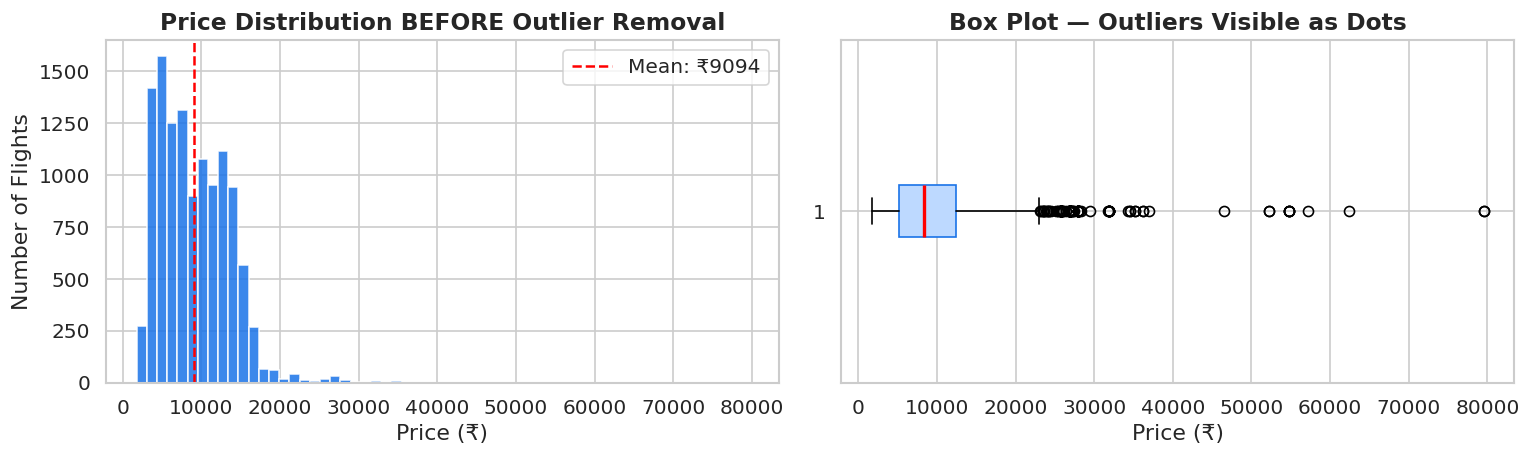

Price range before: ₹1,759.0 to ₹79,512.0
Mean: ₹9,094   Median: ₹8,372


In [ ]:
# ── Visualise price BEFORE outlier removal ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(df['Price'], bins=60, color='#1A73E8', edgecolor='white', alpha=0.85)
axes[0].set_title('Price Distribution BEFORE Outlier Removal')
axes[0].set_xlabel('Price (₹)')
axes[0].set_ylabel('Number of Flights')
axes[0].axvline(df['Price'].mean(), color='red', linestyle='--', label=f'Mean: ₹{df["Price"].mean():.0f}')
axes[0].legend()

# Box plot
axes[1].boxplot(df['Price'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='#BDD9FF', color='#1A73E8'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Box Plot — Outliers Visible as Dots')
axes[1].set_xlabel('Price (₹)')

plt.tight_layout()
plt.savefig('plot_outliers_before.png', bbox_inches='tight')
plt.show()

print(f"Price range before: ₹{df['Price'].min():,} to ₹{df['Price'].max():,}")
print(f"Mean: ₹{df['Price'].mean():,.0f}   Median: ₹{df['Price'].median():,.0f}")

In [ ]:
# ── IQR Method to Remove Outliers ────────────────────────────
Q1 = df['Price'].quantile(0.25)    # 25th percentile
Q3 = df['Price'].quantile(0.75)    # 75th percentile
IQR = Q3 - Q1                      # Interquartile range

# Fence: anything beyond Q3 + 1.5×IQR is an outlier
upper_fence = Q3 + 1.5 * IQR
lower_fence = Q1 - 1.5 * IQR

print(f"Q1 = ₹{Q1:,.0f}")
print(f"Q3 = ₹{Q3:,.0f}")
print(f"IQR = ₹{IQR:,.0f}")
print(f"Upper fence = ₹{upper_fence:,.0f}")

before = len(df)
df = df[(df['Price'] >= lower_fence) & (df['Price'] <= upper_fence)]
after = len(df)

print(f"\nRows removed: {before - after} outliers")
print(f"Price range after: ₹{df['Price'].min():,} to ₹{df['Price'].max():,}")
print("✅ Outliers removed!")

Q1 = ₹5,241
Q3 = ₹12,373
IQR = ₹7,132
Upper fence = ₹23,071

Rows removed: 105 outliers
Price range after: ₹1,759.0 to ₹23,001.0
✅ Outliers removed!


## Step 7: Exploratory Data Analysis (EDA)

Six charts covering the most relevant relationships in the dataset.


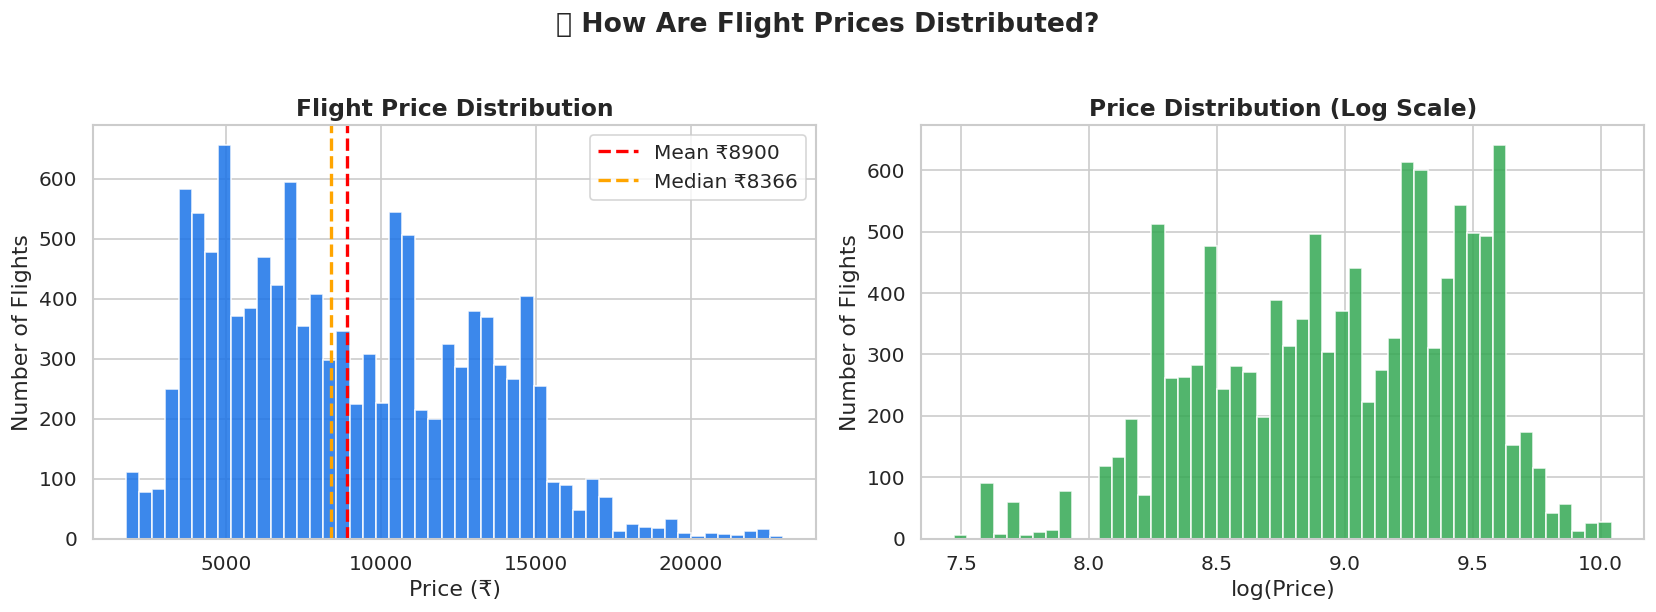

💡 Insight: Most flights cost between ₹4,000 and ₹12,000. A few expensive ones pull the mean up.


In [ ]:
# ══════════════════════════════════════════════════════════════
# CHART 1 & 2: Price Distribution — Raw and Log Scale
# ══════════════════════════════════════════════════════════════
# WHY: Shows that most tickets are in the ₹4,000–₹12,000 range
#      The distribution is right-skewed (few very expensive tickets)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(df['Price'], bins=50, color='#1A73E8', edgecolor='white', alpha=0.85)
axes[0].set_title('Flight Price Distribution')
axes[0].set_xlabel('Price (₹)')
axes[0].set_ylabel('Number of Flights')
axes[0].axvline(df['Price'].mean(),   color='red',    ls='--', lw=2, label=f'Mean ₹{df["Price"].mean():.0f}')
axes[0].axvline(df['Price'].median(), color='orange', ls='--', lw=2, label=f'Median ₹{df["Price"].median():.0f}')
axes[0].legend()

# Log scale — better for skewed data
axes[1].hist(np.log1p(df['Price']), bins=50, color='#34A853', edgecolor='white', alpha=0.85)
axes[1].set_title('Price Distribution (Log Scale)')
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Number of Flights')

fig.suptitle('📊 How Are Flight Prices Distributed?', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart1_price_distribution.png', bbox_inches='tight')
plt.show()

print("💡 Insight: Most flights cost between ₹4,000 and ₹12,000. A few expensive ones pull the mean up.")

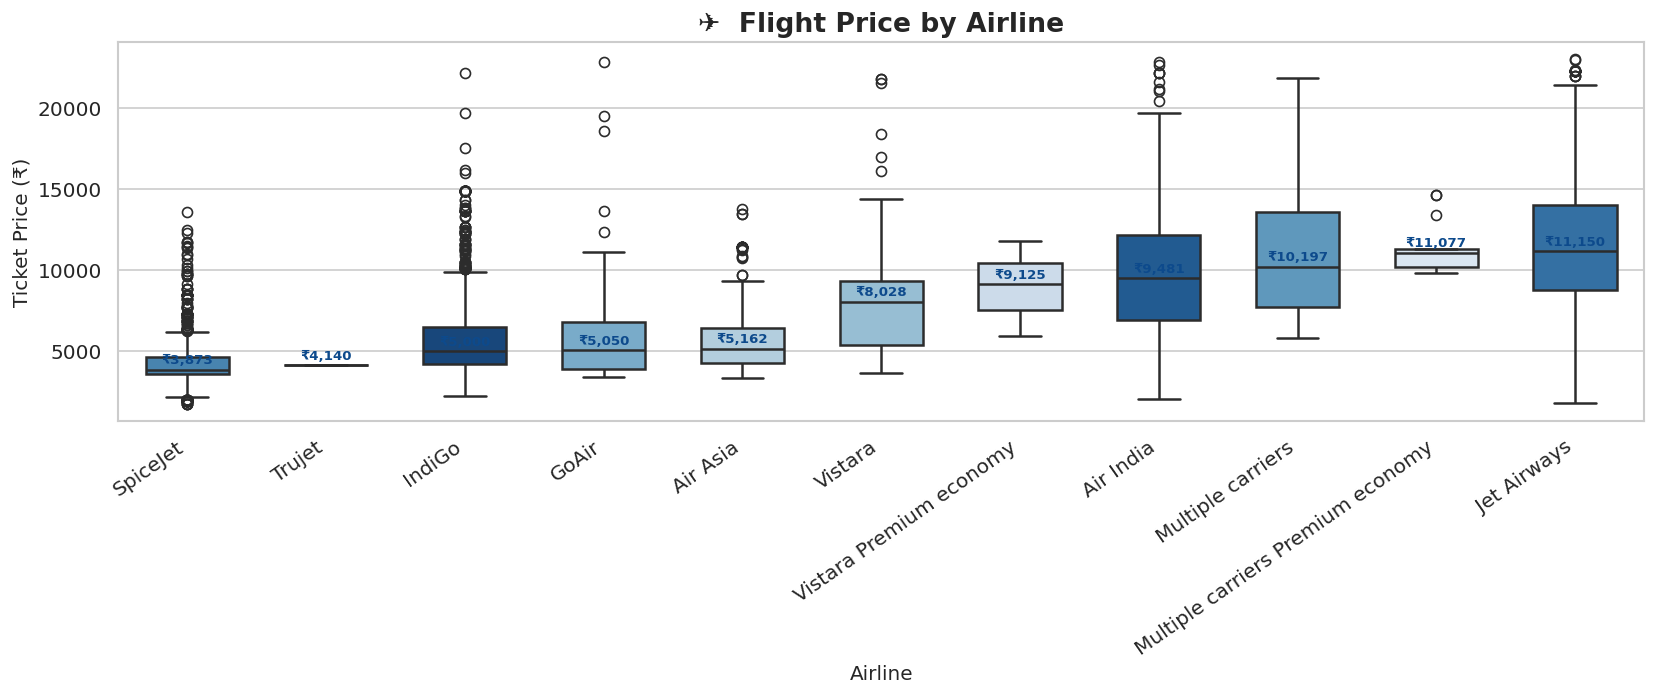

💡 Insight: Jet Airways Business and Vistara Premium Economy are the most expensive.
   IndiGo, SpiceJet and GoAir are budget-friendly options.


In [ ]:
# ══════════════════════════════════════════════════════════════
# CHART 2: Price vs Airline (Box Plot)
# ══════════════════════════════════════════════════════════════
# WHY: Shows which airlines are expensive vs budget
#      Box plots show median, spread, and any remaining outliers

# We need the original airline names from the one-hot encoded columns
df_plot = df.copy()

# Get all columns that were created from the 'Airline' feature via one-hot encoding
airline_ohe_cols = [col for col in df_plot.columns if col.startswith('Airline_')]

# Create a new 'Airline_Name' column by inferring the airline from the OHE columns.
# If all OHE columns for a row are 0, it implies the 'first' airline that was dropped by drop_first=True.
# Based on alphabetical order of unique airlines in the original dataset, 'Air Asia' was dropped.
def get_airline_from_ohe(row):
    for col in airline_ohe_cols:
        if row[col] == 1:
            return col.replace('Airline_', '')
    # If none of the one-hot encoded columns are 1, it means the airline is the one that was dropped.
    # Assuming 'Air Asia' was the first alphabetically and thus dropped by pd.get_dummies(drop_first=True).
    return 'Air Asia'

df_plot['Airline_Name'] = df_plot.apply(get_airline_from_ohe, axis=1)

fig, ax = plt.subplots(figsize=(14, 6))

# Order airlines by median price
order = df_plot.groupby('Airline_Name')['Price'].median().sort_values().index

colors = sns.color_palette('Blues_r', len(order))
sns.boxplot(data=df_plot, x='Airline_Name', y='Price', order=order,
            palette=colors, hue='Airline_Name', legend=False, ax=ax, width=0.6, linewidth=1.5)

ax.set_title('✈️  Flight Price by Airline', fontsize=16, fontweight='bold')
ax.set_xlabel('Airline', fontsize=12)
ax.set_ylabel('Ticket Price (₹)', fontsize=12)
plt.xticks(rotation=35, ha='right')

# Add median labels
for i, airline in enumerate(order):
    med = df_plot[df_plot['Airline_Name'] == airline]['Price'].median()
    ax.text(i, med + 200, f'₹{med:,.0f}', ha='center', va='bottom', fontsize=8,
            fontweight='bold', color='#0D4A8C')

plt.tight_layout()
plt.savefig('chart2_price_airline.png', bbox_inches='tight')
plt.show()

print("💡 Insight: Jet Airways Business and Vistara Premium Economy are the most expensive.")
print("   IndiGo, SpiceJet and GoAir are budget-friendly options.")


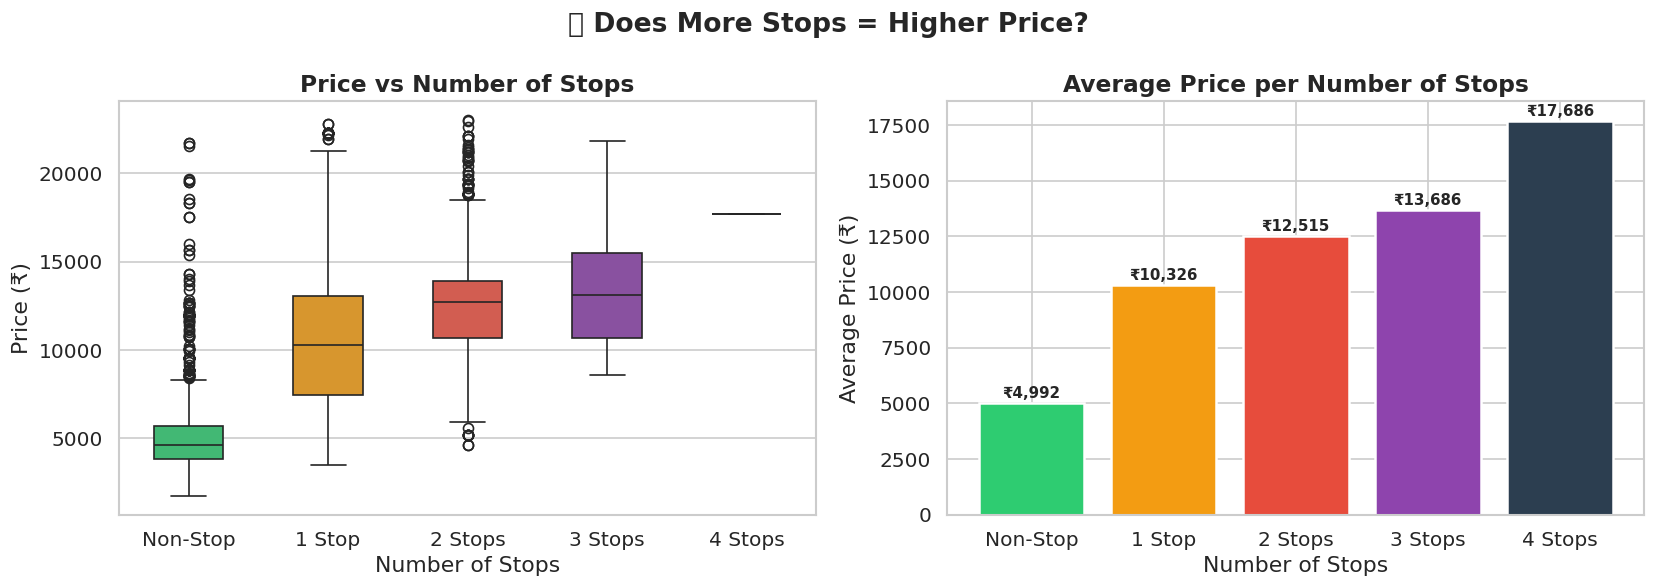

💡 Insight: Flights with 1-2 stops are often MORE expensive than direct flights.
   This is because connecting flights often cover longer total distances.


In [ ]:
# ══════════════════════════════════════════════════════════════
# CHART 3: Price vs Number of Stops
# ══════════════════════════════════════════════════════════════
# WHY: More stops often means longer journey → higher price
#      This is one of the most important features!

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stop_labels = {0: 'Non-Stop', 1: '1 Stop', 2: '2 Stops', 3: '3 Stops', 4: '4 Stops'}
df_plot2 = df.copy()
df_plot2['Stops_Label'] = df_plot2['Total_Stops'].map(stop_labels)

# Box plot
stop_order = ['Non-Stop', '1 Stop', '2 Stops', '3 Stops', '4 Stops']
colors2 = ['#2ECC71', '#F39C12', '#E74C3C', '#8E44AD', '#2C3E50']
sns.boxplot(data=df_plot2, x='Stops_Label', y='Price', order=stop_order,
            palette=colors2, ax=axes[0], width=0.5)
axes[0].set_title('Price vs Number of Stops')
axes[0].set_xlabel('Number of Stops')
axes[0].set_ylabel('Price (₹)')

# Bar chart of average price per stops
avg_price = df_plot2.groupby('Stops_Label')['Price'].mean().reindex(stop_order)
bars = axes[1].bar(stop_order, avg_price.values, color=colors2, edgecolor='white', linewidth=1.5)
axes[1].set_title('Average Price per Number of Stops')
axes[1].set_xlabel('Number of Stops')
axes[1].set_ylabel('Average Price (₹)')
for bar, val in zip(bars, avg_price.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'₹{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.suptitle('🛑 Does More Stops = Higher Price?', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_price_stops.png', bbox_inches='tight')
plt.show()

print("💡 Insight: Flights with 1-2 stops are often MORE expensive than direct flights.")
print("   This is because connecting flights often cover longer total distances.")

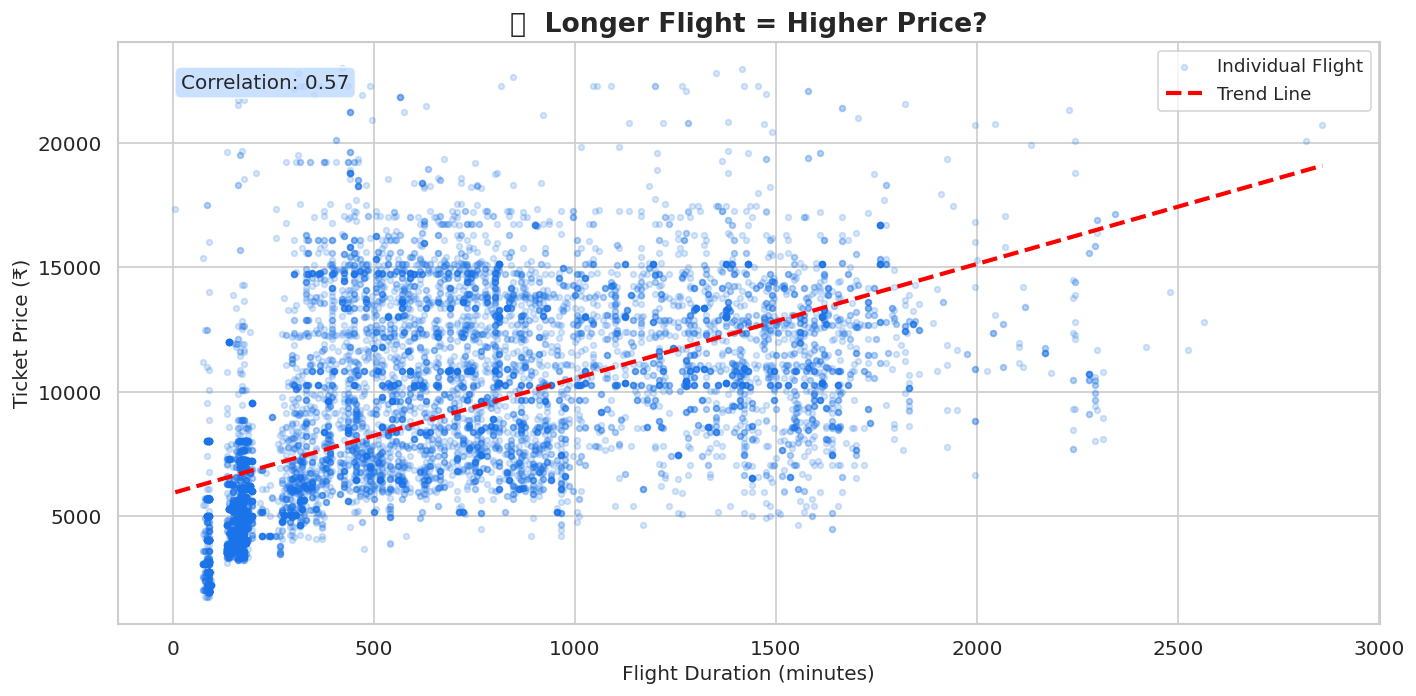

💡 Insight: Correlation = 0.57 — positive relationship confirmed!
   Longer duration → higher price, but relationship is not perfectly linear.


In [ ]:
# ══════════════════════════════════════════════════════════════
# CHART 4: Price vs Duration (Scatter Plot)
# ══════════════════════════════════════════════════════════════
# WHY: Longer flights should cost more — let's verify this!
#      We add a trend line to show the relationship clearly.

fig, ax = plt.subplots(figsize=(12, 6))

# Scatter plot — each dot = one flight
ax.scatter(df['Duration_mins'], df['Price'],
           alpha=0.18, s=12, color='#1A73E8', label='Individual Flight')

# Trend line (line of best fit)
z = np.polyfit(df['Duration_mins'], df['Price'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Duration_mins'].min(), df['Duration_mins'].max(), 200)
ax.plot(x_line, p(x_line), color='red', linewidth=2.5, linestyle='--', label='Trend Line')

ax.set_title('⏱️  Longer Flight = Higher Price?', fontsize=16, fontweight='bold')
ax.set_xlabel('Flight Duration (minutes)', fontsize=12)
ax.set_ylabel('Ticket Price (₹)', fontsize=12)
ax.legend(fontsize=11)

# Add annotation for the trend
corr = df['Duration_mins'].corr(df['Price'])
ax.text(0.05, 0.92, f'Correlation: {corr:.2f}', transform=ax.transAxes,
        fontsize=12, bbox=dict(boxstyle='round', facecolor='#BDD9FF', alpha=0.8))

plt.tight_layout()
plt.savefig('chart4_price_duration.png', bbox_inches='tight')
plt.show()

print(f"💡 Insight: Correlation = {corr:.2f} — positive relationship confirmed!")
print("   Longer duration → higher price, but relationship is not perfectly linear.")

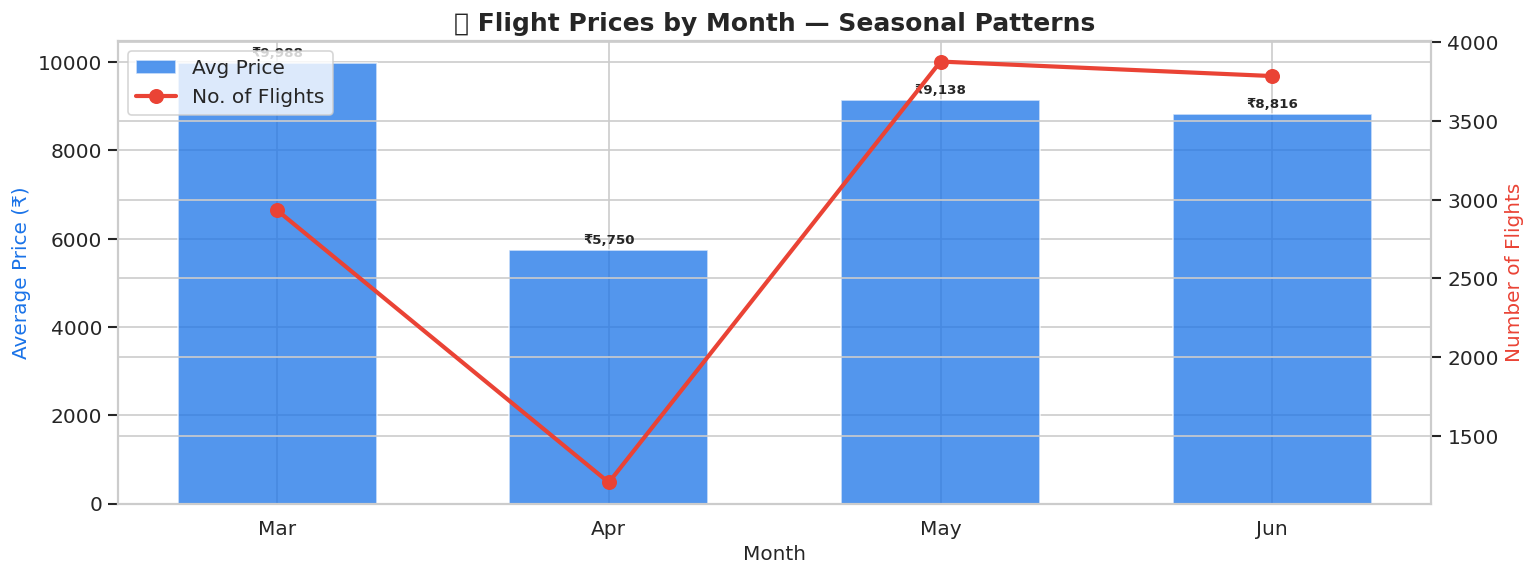

💡 Insight: March–May prices are higher — summer travel peak season in India.
   The dataset covers mostly Mar–Jun 2019 (88% of records).


In [ ]:
# ══════════════════════════════════════════════════════════════
# CHART 5: Price by Journey Month (Seasonality)
# ══════════════════════════════════════════════════════════════
# WHY: Airlines charge more during peak travel months!

month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

monthly = df.groupby('Journey_month')['Price'].agg(['mean', 'count']).reset_index()
monthly['month_name'] = monthly['Journey_month'].map(month_names)

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()   # Second y-axis for flight count

bars = ax1.bar(monthly['month_name'], monthly['mean'],
               color='#1A73E8', alpha=0.75, label='Avg Price', width=0.6)
ax2.plot(monthly['month_name'], monthly['count'],
         color='#EA4335', marker='o', linewidth=2.5, markersize=8, label='No. of Flights')

ax1.set_title('📅 Flight Prices by Month — Seasonal Patterns', fontsize=15, fontweight='bold')
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Average Price (₹)', color='#1A73E8', fontsize=12)
ax2.set_ylabel('Number of Flights', color='#EA4335', fontsize=12)

for bar, val in zip(bars, monthly['mean']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
             f'₹{val:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig('chart5_price_month.png', bbox_inches='tight')
plt.show()

print("💡 Insight: March–May prices are higher — summer travel peak season in India.")
print("   The dataset covers mostly Mar–Jun 2019 (88% of records).")

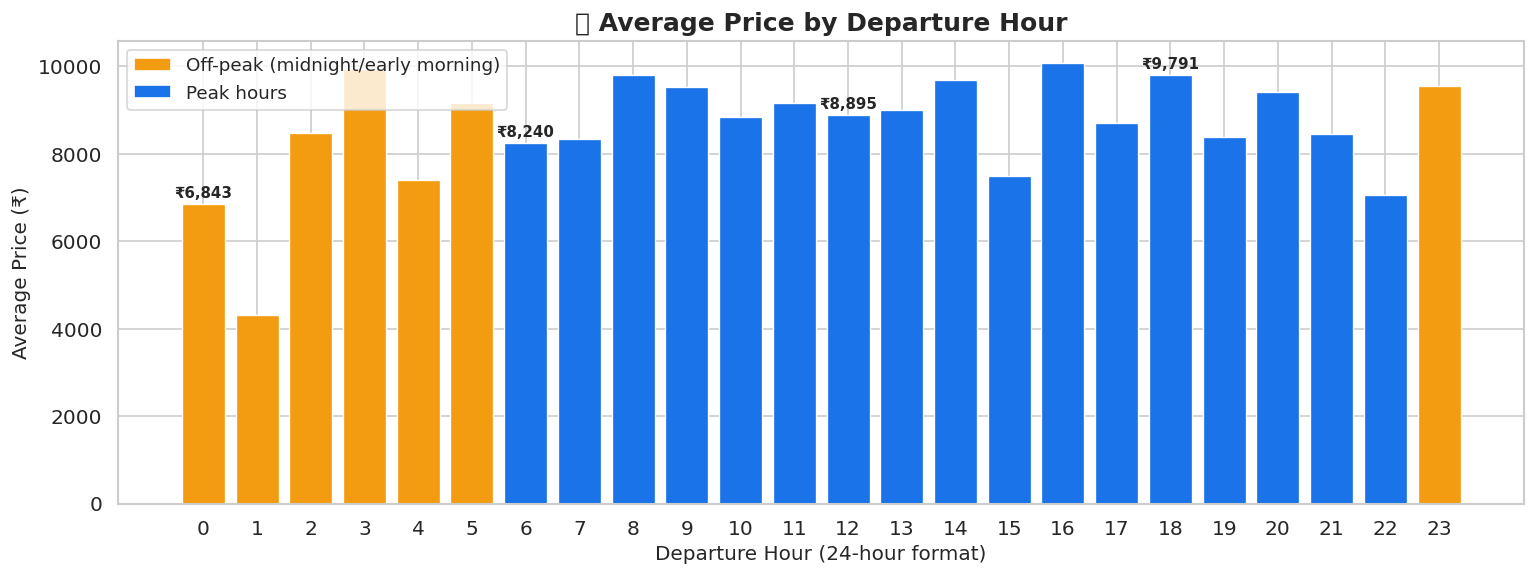

💡 Insight: Mid-morning and afternoon flights (8am–4pm) tend to cost more.
   Very early morning flights (4–6am) are cheapest!


In [ ]:
# ══════════════════════════════════════════════════════════════
# CHART 6: Price by Departure Hour (Time of Day)
# ══════════════════════════════════════════════════════════════
# WHY: Do early morning or late-night flights cost less?

hourly = df.groupby('Dep_hour')['Price'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
colors_hour = ['#F39C12' if (h < 6 or h > 22) else '#1A73E8' for h in hourly['Dep_hour']]
bars = ax.bar(hourly['Dep_hour'], hourly['Price'], color=colors_hour, edgecolor='white', linewidth=0.8)

ax.set_title('🕐 Average Price by Departure Hour', fontsize=15, fontweight='bold')
ax.set_xlabel('Departure Hour (24-hour format)', fontsize=12)
ax.set_ylabel('Average Price (₹)', fontsize=12)
ax.set_xticks(range(0, 24))

# Add labels at peak hours
for bar in bars:
    h = bar.get_x() + bar.get_width() / 2
    if int(h) in [0, 6, 12, 18]:
        ax.text(h, bar.get_height() + 80, f'₹{bar.get_height():,.0f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#F39C12', label='Off-peak (midnight/early morning)'),
                   Patch(facecolor='#1A73E8', label='Peak hours')]
ax.legend(handles=legend_elements, fontsize=11)

plt.tight_layout()
plt.savefig('chart6_price_hour.png', bbox_inches='tight')
plt.show()

print("💡 Insight: Mid-morning and afternoon flights (8am–4pm) tend to cost more.")
print("   Very early morning flights (4–6am) are cheapest!")

## Step 7b: Multicollinearity Check — Variance Inflation Factor (VIF)

$$\text{VIF}_j = \frac{1}{1 - R^2_j}$$

To compute VIF for feature $j$, we regress $x_j$ on all other features and measure $R^2_j$.
High $R^2_j$ means other features predict $x_j$ well — they carry overlapping information.

| VIF Range | Diagnosis | Action |
|---|---|---|
| 1–5 | Low — acceptable | None |
| 5–10 | Moderate | Consider Ridge |
| > 10 | Severe | Ridge strongly recommended |

**Why this matters:** High multicollinearity inflates standard errors of $\hat{\beta}$,
making coefficient estimates unstable. Ridge adds $\lambda I$ to $X^TX$,
guaranteeing invertibility: $\hat{\beta}_{Ridge} = (X^TX + \lambda I)^{-1}X^Ty$


In [ ]:
if HAS_VIF:
    # Compute VIF for numeric engineered features only
    # (OHE dummies are excluded — multicollinearity there is expected by design)
    vif_candidates = ['Journey_day', 'Journey_month', 'Journey_weekday', 'is_weekend',
                      'is_peak_season', 'Dep_hour', 'Dep_min', 'dep_tod_bucket', 'is_peak_dep',
                      'Arrival_hour', 'Arrival_min', 'is_overnight', 'Duration_mins',
                      'Total_Stops', 'route_stops_count', 'has_layover', 'route_distance_km',
                      'duration_per_stop', 'no_baggage', 'no_meal', 'is_business', 'is_redeye']

    vif_cols = [c for c in vif_candidates if c in df.columns]
    X_vif    = df[vif_cols].dropna()

    vif_df = pd.DataFrame({
        'Feature': vif_cols,
        'VIF':     [variance_inflation_factor(X_vif.values, i)
                    for i in range(len(vif_cols))]
    }).sort_values('VIF', ascending=False)

    print("VARIANCE INFLATION FACTORS")
    print("=" * 45)
    print(vif_df.to_string(index=False))

    high_vif = vif_df[vif_df['VIF'] > 10]
    if len(high_vif):
        print(f"\nVIF > 10 detected: {high_vif['Feature'].tolist()}")
        print("-> Ridge regression is recommended to handle multicollinearity.")
    else:
        print("\nAll VIF values acceptable (< 10). Ridge still useful as regularisation.")
else:
    print("Install statsmodels: pip install statsmodels")


VARIANCE INFLATION FACTORS
          Feature        VIF
route_stops_count 244.848350
      Total_Stops 160.202324
    Duration_mins 140.937739
duration_per_stop 113.076982
      has_layover  12.092515
  Journey_weekday   3.123174
       is_weekend   3.113005
     is_overnight   2.555955
     Arrival_hour   2.462206
   dep_tod_bucket   2.378942
         Dep_hour   2.263648
route_distance_km   1.808902
          no_meal   1.104215
   is_peak_season   1.088397
      Arrival_min   1.084430
       no_baggage   1.082081
    Journey_month   1.081355
      is_peak_dep   1.077124
      Journey_day   1.041933
          Dep_min   1.027905
        is_redeye   1.001825
      is_business        NaN

VIF > 10 detected: ['route_stops_count', 'Total_Stops', 'Duration_mins', 'duration_per_stop', 'has_layover']
-> Ridge regression is recommended to handle multicollinearity.


## Step 8: Feature Selection

Pearson correlation between each feature and `Price` is computed.
Features with absolute correlation below 0.05 are dropped — they carry too little signal.


In [ ]:
X = df.drop('Price', axis=1)
y = df['Price']

print(f"Features: {X.shape[1]} columns")
print(f"Target  : {y.shape[0]:,} values")


Features: 42 columns
Target  : 11,800 values


In [ ]:
corr_with_price = X.corrwith(y).abs().sort_values(ascending=False)

print("Correlation of each feature with Price:")
print(corr_with_price.round(4).to_string())

threshold = 0.05
selected_features = corr_with_price[corr_with_price > threshold].index.tolist()
dropped_features  = corr_with_price[corr_with_price <= threshold].index.tolist()

print(f"\nSelected: {len(selected_features)} features")
print(f"Dropped : {len(dropped_features)} low-correlation features -> {dropped_features}")


Correlation of each feature with Price:
has_layover                                  0.6723
Total_Stops                                  0.6697
route_stops_count                            0.6697
Duration_mins                                0.5744
duration_per_stop                            0.5362
route_distance_km                            0.4789
Airline_Jet Airways                          0.4500
Airline_IndiGo                               0.3885
Destination_Delhi                            0.3417
Destination_Cochin                           0.3311
Source_Delhi                                 0.3311
Airline_SpiceJet                             0.3268
Destination_Hyderabad                        0.2565
Source_Mumbai                                0.2565
no_baggage                                   0.2267
Source_Chennai                               0.1946
Destination_Kolkata                          0.1946
Airline_Multiple carriers                    0.1624
Journey_day             

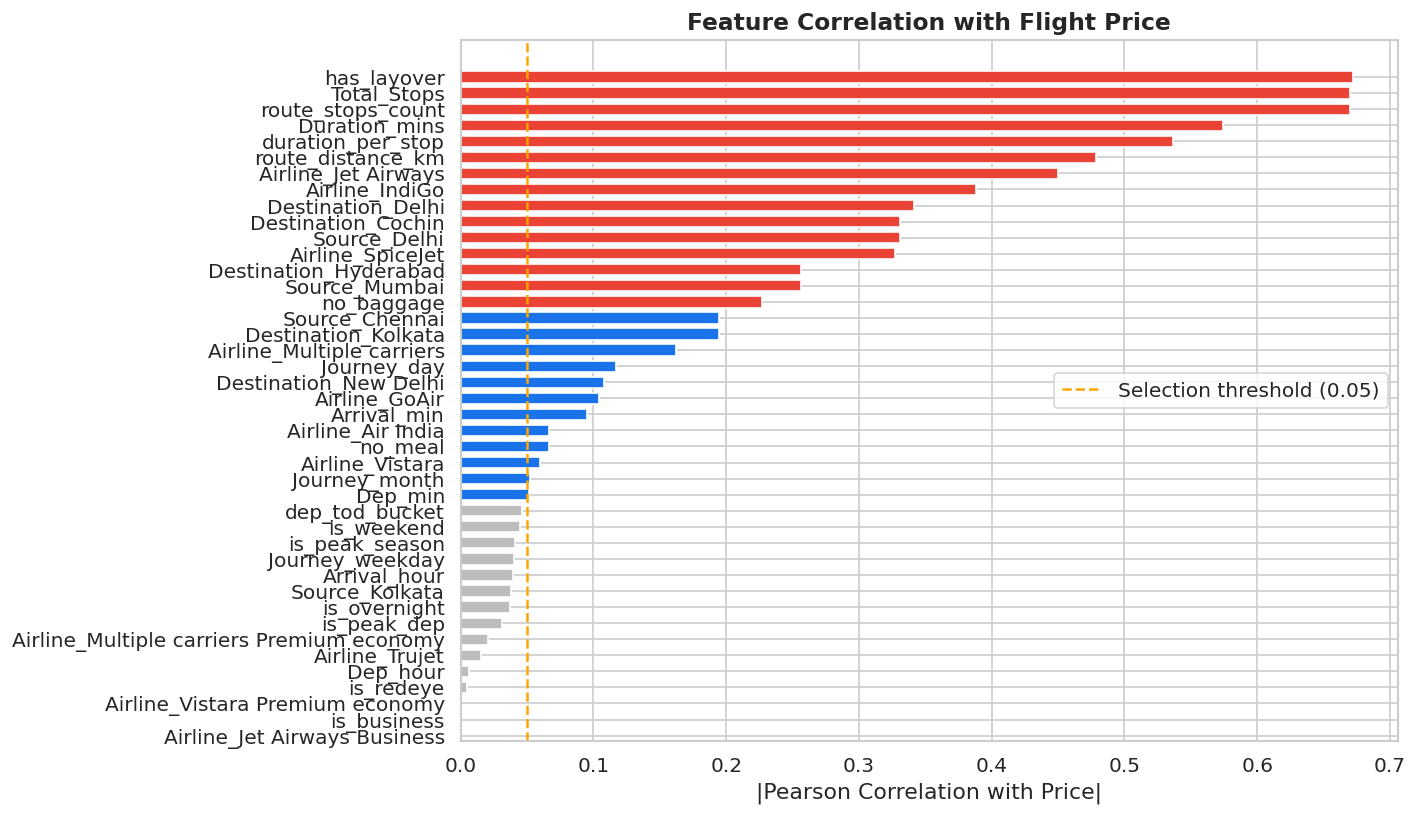


Feature matrix: 27 columns retained


In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#EA4335' if c > 0.2 else '#1A73E8' if c > 0.05 else '#BDBDBD'
          for c in corr_with_price.values]

ax.barh(corr_with_price.index[::-1], corr_with_price.values[::-1],
        color=colors[::-1], edgecolor='white', height=0.7)
ax.axvline(0.05, color='orange', linestyle='--', linewidth=1.5,
           label='Selection threshold (0.05)')
ax.set_xlabel('|Pearson Correlation with Price|')
ax.set_title('Feature Correlation with Flight Price')
ax.legend()
plt.tight_layout()
plt.show()

X = X[selected_features]
print(f"\nFeature matrix: {X.shape[1]} columns retained")


## Step 9: Train/Test Split

80% training, 20% test. `random_state=42` for reproducibility.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(f"Total  : {len(X):,} rows")
print(f"Train  : {len(X_train):,} rows  (80%)")
print(f"Test   : {len(X_test):,} rows  (20%)")


Total  : 11,800 rows
Train  : 9,440 rows  (80%)
Test   : 2,360 rows  (20%)


## Step 10: Linear Regression

Trains a regression model to predict the exact ticket price.

**Evaluation metrics:**
- **MAE** — average absolute error in Rs
- **RMSE** — penalises large errors more than MAE
- **R2** — proportion of price variance explained by the model
- **CV R2** — 5-fold cross-validation estimate of generalisation


In [ ]:
def evaluate_regression(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    mae   = mean_absolute_error(y_te, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_te, y_pred))
    r2    = r2_score(y_te, y_pred)
    cv_r2 = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2').mean()

    print(f"  {name}")
    print(f"    MAE  : Rs {mae:,.0f}")
    print(f"    RMSE : Rs {rmse:,.0f}")
    print(f"    R2   : {r2:.4f}  ({r2*100:.1f}% variance explained)")
    print(f"    CV R2: {cv_r2:.4f}")
    print()

    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'CV_R2': cv_r2, 'Predictions': y_pred, 'Object': model}


In [ ]:
lr_model  = LinearRegression()
lr_result = evaluate_regression('Linear Regression', lr_model, X_train, y_train, X_test, y_test)

coef_df = pd.DataFrame({
    'Feature'    : X_train.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)


print("Learned coefficients (top 10):")
print(coef_df.head(10).to_string(index=False))
print(f"\nIntercept: Rs {lr_model.intercept_:,.2f}")


  Linear Regression
    MAE  : Rs 1,615
    RMSE : Rs 2,146
    R2   : 0.7155  (71.6% variance explained)
    CV R2: 0.7158

Learned coefficients (top 10):
                  Feature  Coefficient
      Airline_Jet Airways  5638.869891
                  no_meal -3402.402904
Airline_Multiple carriers  3300.149984
          Airline_Vistara  1656.031833
        Airline_Air India  1570.177820
        route_stops_count  1444.150546
              Total_Stops  1444.150546
    Destination_New Delhi  1184.232488
        Destination_Delhi  -573.071417
            Journey_month  -320.174380

Intercept: Rs 3,634.17


## Step 11: Regression Evaluation — Actual vs Predicted

**Scatter plot:** dots close to the diagonal line = accurate predictions.  
**Residual plot:** well-behaved residuals form a symmetric bell curve centred at zero.


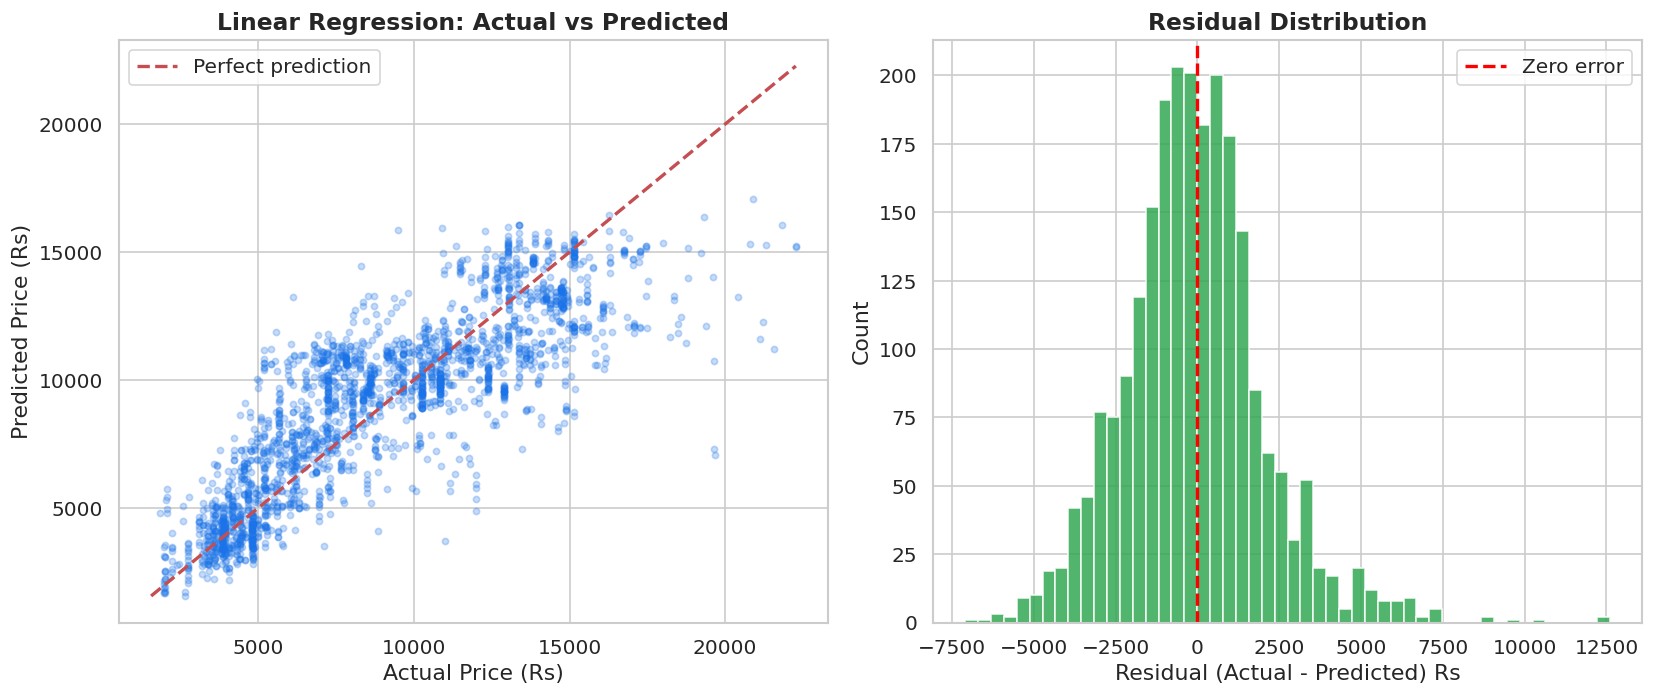

Mean residual : Rs -91.7  (should be close to 0)
Std of residuals: Rs 2,145


In [ ]:
lr_pred = lr_result['Predictions']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, lr_pred, alpha=0.25, s=14, color='#1A73E8')
lims = [min(y_test.min(), lr_pred.min()), max(y_test.max(), lr_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Price (Rs)')
axes[0].set_ylabel('Predicted Price (Rs)')
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].legend()

residuals = y_test.values - lr_pred
axes[1].hist(residuals, bins=50, color='#34A853', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', lw=2, label='Zero error')
axes[1].set_xlabel('Residual (Actual - Predicted) Rs')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Mean residual : Rs {residuals.mean():,.1f}  (should be close to 0)")
print(f"Std of residuals: Rs {residuals.std():,.0f}")


## Step 11b: OLS Assumption Diagnostics

For Linear Regression to be statistically valid, four assumptions must hold.
Checking them answers **why we need non-linear models like Random Forest**.

| Plot | Assumption Tested | What to look for |
|---|---|---|
| Residuals vs Fitted | Linearity + Homoscedasticity | Random scatter around zero |
| Scale-Location | Homoscedasticity | Flat horizontal band |
| Q-Q Plot | Normality of residuals | Points on the diagonal |

If these are violated, OLS estimates are no longer BLUE (Best Linear Unbiased Estimator).


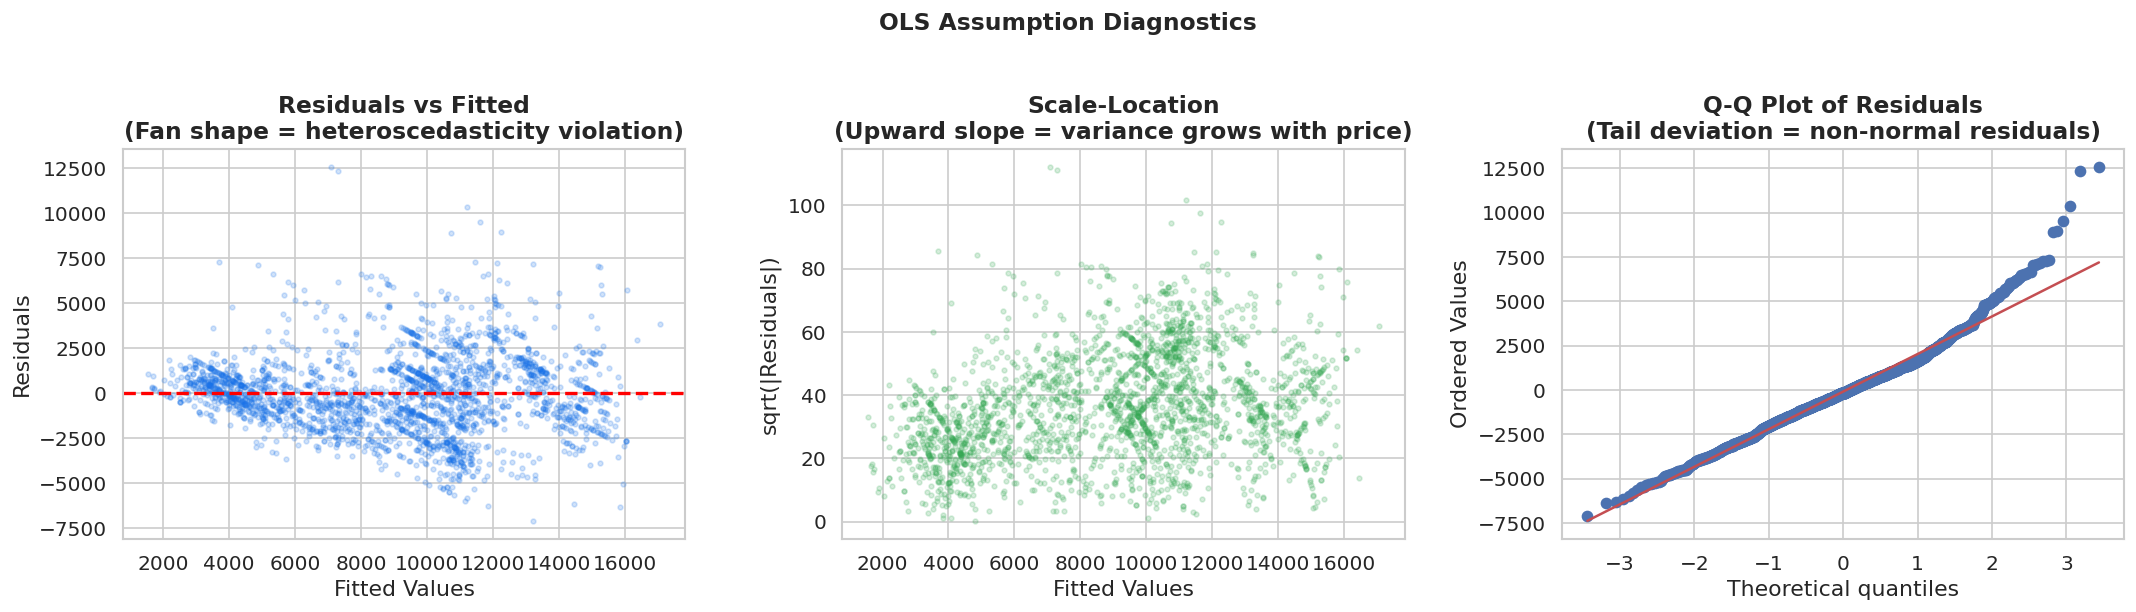

Shapiro-Wilk on residuals: W=0.9700, p=1.35e-08

CONCLUSION:
  Residuals vs Fitted -> fan shape visible -> heteroscedasticity violated
  Q-Q Plot            -> tail deviation  -> residuals not normal
  -> These violations statistically JUSTIFY using Random Forest (no OLS assumptions needed).


In [ ]:
# OLS diagnostics — run on the linear regression results from Step 11
_fitted    = lr_result['Predictions']
_residuals = y_test.values - _fitted

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Residuals vs Fitted (Linearity + Homoscedasticity)
axes[0].scatter(_fitted, _residuals, alpha=0.2, s=8, color='#1A73E8')
axes[0].axhline(0, color='red', ls='--', lw=2)
axes[0].set_xlabel('Fitted Values'); axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted\n(Fan shape = heteroscedasticity violation)')

# Plot 2: Scale-Location (Homoscedasticity)
axes[1].scatter(_fitted, np.sqrt(np.abs(_residuals)), alpha=0.2, s=8, color='#34A853')
axes[1].set_xlabel('Fitted Values'); axes[1].set_ylabel('sqrt(|Residuals|)')
axes[1].set_title('Scale-Location\n(Upward slope = variance grows with price)')

# Plot 3: Q-Q Plot (Normality)
probplot(_residuals, plot=axes[2])
axes[2].set_title('Q-Q Plot of Residuals\n(Tail deviation = non-normal residuals)')

plt.suptitle('OLS Assumption Diagnostics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

sw_stat, sw_p = stats.shapiro(_residuals[:500])
print(f"Shapiro-Wilk on residuals: W={sw_stat:.4f}, p={sw_p:.2e}")
print()
print("CONCLUSION:")
print("  Residuals vs Fitted -> fan shape visible -> heteroscedasticity violated")
print("  Q-Q Plot            -> tail deviation  -> residuals not normal")
print("  -> These violations statistically JUSTIFY using Random Forest (no OLS assumptions needed).")


## Step 12: Logistic Regression — Binary Classification

The regression task is reframed as a classification problem:

> **Is this flight Cheap or Expensive?**

Flights priced above the median are labelled **Expensive (1)**.  
Flights at or below the median are labelled **Cheap (0)**.

Logistic Regression applies the sigmoid function to a linear combination of features:

```
z = w1*x1 + w2*x2 + ... + b
P(Expensive) = 1 / (1 + e^(-z))
```

If `P(Expensive) > 0.5` the model predicts Expensive, otherwise Cheap.


In [ ]:
price_median = df['Price'].median()
y_class = (df['Price'] > price_median).astype(int)

print(f"Median price (threshold): Rs {price_median:,.0f}")
print(f"\nClass distribution:")
print(f"  Cheap (0)     : {(y_class == 0).sum():,}  ({(y_class==0).mean()*100:.1f}%)")
print(f"  Expensive (1) : {(y_class == 1).sum():,}  ({(y_class==1).mean()*100:.1f}%)")


Median price (threshold): Rs 8,366

Class distribution:
  Cheap (0)     : 5,906  (50.1%)
  Expensive (1) : 5,894  (49.9%)


In [ ]:
X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X, y_class,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_class
)

print(f"Training set : {X_cls_train.shape[0]:,} rows")
print(f"Test set     : {X_cls_test.shape[0]:,} rows")
print(f"Train class balance: {y_cls_train.value_counts().to_dict()}")
print(f"Test  class balance: {y_cls_test.value_counts().to_dict()}")


Training set : 9,440 rows
Test set     : 2,360 rows
Train class balance: {0: 4725, 1: 4715}
Test  class balance: {0: 1181, 1: 1179}


In [ ]:
scaler = StandardScaler()
X_cls_train_sc = scaler.fit_transform(X_cls_train)
X_cls_test_sc  = scaler.transform(X_cls_test)

print("StandardScaler applied (fit on train only).")
print(f"  Train mean post-scaling: {X_cls_train_sc.mean():.6f}")
print(f"  Train std  post-scaling: {X_cls_train_sc.std():.6f}")


StandardScaler applied (fit on train only).
  Train mean post-scaling: -0.000000
  Train std  post-scaling: 1.000000


In [ ]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_cls_train_sc, y_cls_train)

y_cls_pred  = log_reg.predict(X_cls_test_sc)
y_cls_proba = log_reg.predict_proba(X_cls_test_sc)[:, 1]

cls_accuracy = accuracy_score(y_cls_test, y_cls_pred)
roc_auc      = roc_auc_score(y_cls_test, y_cls_proba)

print(f"Test Accuracy : {cls_accuracy:.4f}")
print(f"ROC-AUC Score : {roc_auc:.4f}")
print()
print("Classification Report:")
print(classification_report(y_cls_test, y_cls_pred,
                             target_names=['Cheap (0)', 'Expensive (1)']))


Test Accuracy : 0.8792
ROC-AUC Score : 0.9453

Classification Report:
               precision    recall  f1-score   support

    Cheap (0)       0.91      0.85      0.88      1181
Expensive (1)       0.86      0.91      0.88      1179

     accuracy                           0.88      2360
    macro avg       0.88      0.88      0.88      2360
 weighted avg       0.88      0.88      0.88      2360



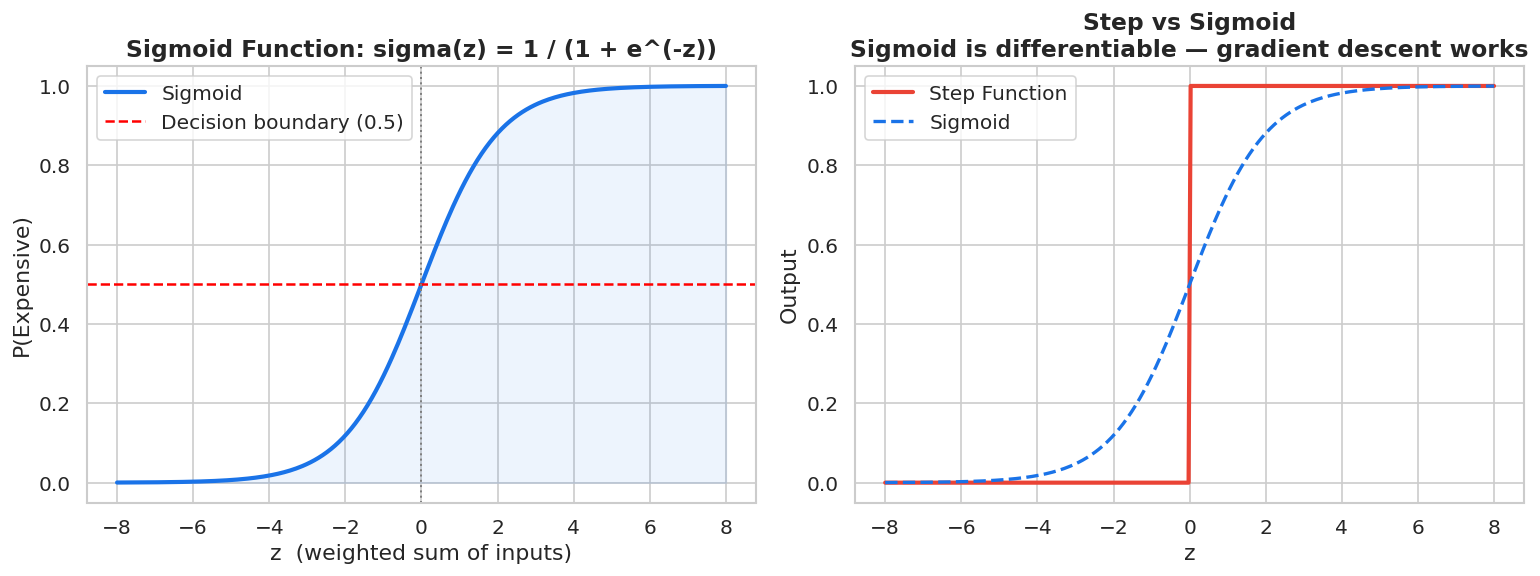

In [ ]:
z = np.linspace(-8, 8, 300)
sigmoid = 1 / (1 + np.exp(-z))
step    = (z >= 0).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(z, sigmoid, color='#1A73E8', lw=2.5, label='Sigmoid')
axes[0].axhline(0.5, color='red', linestyle='--', lw=1.5, label='Decision boundary (0.5)')
axes[0].axvline(0, color='grey', linestyle=':', lw=1.2)
axes[0].fill_between(z, sigmoid, alpha=0.08, color='#1A73E8')
axes[0].set_title('Sigmoid Function: sigma(z) = 1 / (1 + e^(-z))')
axes[0].set_xlabel('z  (weighted sum of inputs)')
axes[0].set_ylabel('P(Expensive)')
axes[0].legend()

axes[1].plot(z, step,    color='#EA4335', lw=2.5, label='Step Function')
axes[1].plot(z, sigmoid, color='#1A73E8', lw=2,   linestyle='--', label='Sigmoid')
axes[1].set_title('Step vs Sigmoid\nSigmoid is differentiable — gradient descent works')
axes[1].set_xlabel('z')
axes[1].set_ylabel('Output')
axes[1].legend()

plt.tight_layout()
plt.show()


## Step 13: Classification Metrics

| Metric | Formula | Meaning |
|--------|---------|---------|
| Accuracy | (TP+TN) / Total | Overall correct predictions |
| Precision | TP / (TP+FP) | Of flights predicted Expensive, how many truly were? |
| Recall | TP / (TP+FN) | Of all truly Expensive flights, how many did the model catch? |
| F1-Score | 2 * (P*R) / (P+R) | Harmonic mean of Precision and Recall |

**Confusion Matrix:**

```
                Predicted
             Cheap | Expensive
Actual Cheap |  TN  |    FP   |
       Exp.  |  FN  |    TP   |
```


Confusion Matrix breakdown:
  TN (Cheap predicted as Cheap)         : 1001
  FP (Cheap predicted as Expensive)     :  180  <- Type I error
  FN (Expensive predicted as Cheap)     :  105  <- Type II error
  TP (Expensive predicted as Expensive) : 1074


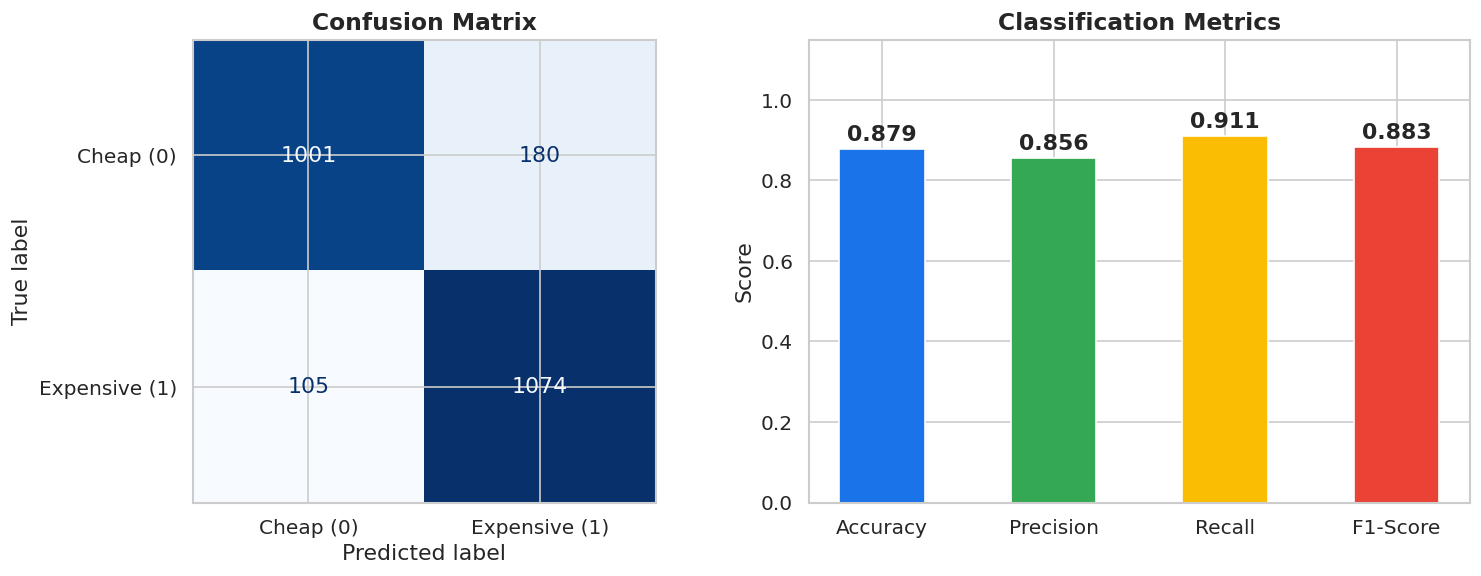

In [ ]:
cm = confusion_matrix(y_cls_test, y_cls_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix breakdown:")
print(f"  TN (Cheap predicted as Cheap)         : {tn:4d}")
print(f"  FP (Cheap predicted as Expensive)     : {fp:4d}  <- Type I error")
print(f"  FN (Expensive predicted as Cheap)     : {fn:4d}  <- Type II error")
print(f"  TP (Expensive predicted as Expensive) : {tp:4d}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Cheap (0)', 'Expensive (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

cls_metrics = {
    'Accuracy' : accuracy_score(y_cls_test, y_cls_pred),
    'Precision': precision_score(y_cls_test, y_cls_pred),
    'Recall'   : recall_score(y_cls_test, y_cls_pred),
    'F1-Score' : f1_score(y_cls_test, y_cls_pred)
}
pal = ['#1A73E8', '#34A853', '#FBBC04', '#EA4335']
bars = axes[1].bar(cls_metrics.keys(), cls_metrics.values(),
                   color=pal, edgecolor='white', width=0.5)
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('Score')
axes[1].set_title('Classification Metrics')
for bar, val in zip(bars, cls_metrics.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 f'{val:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


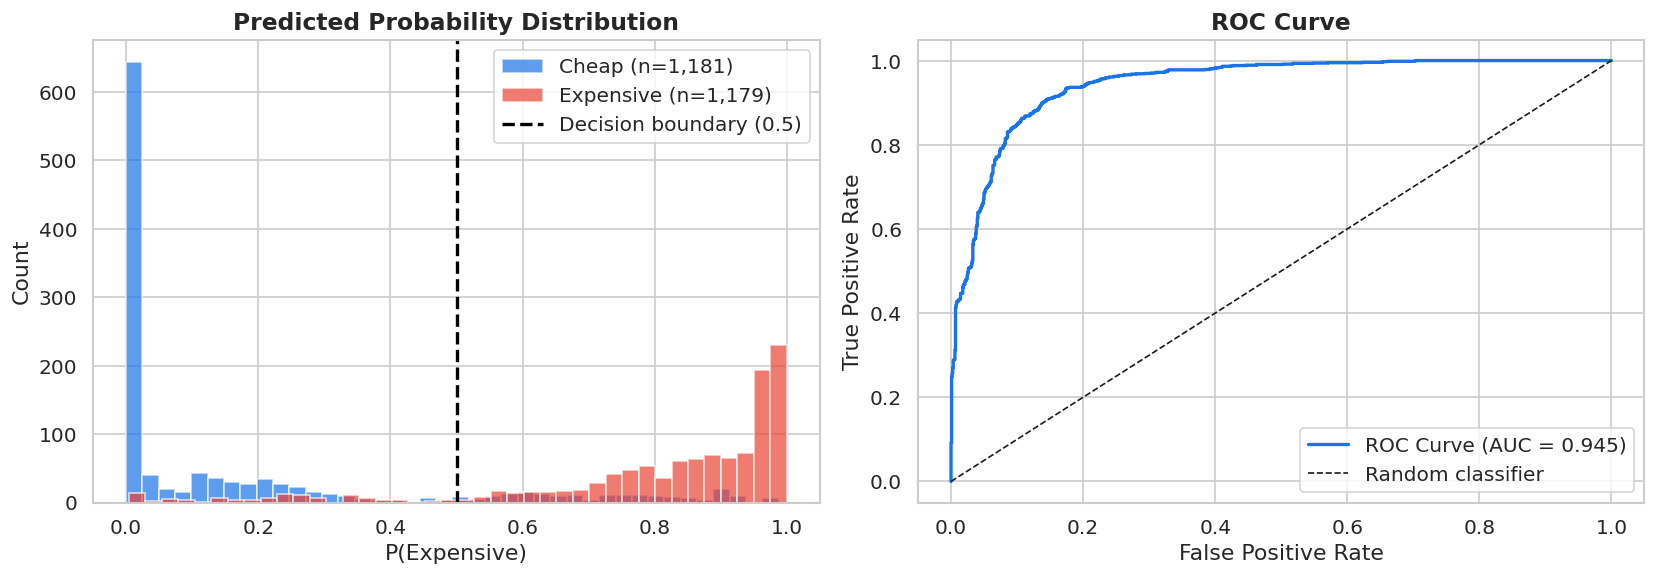

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cheap_proba     = y_cls_proba[y_cls_test == 0]
expensive_proba = y_cls_proba[y_cls_test == 1]

axes[0].hist(cheap_proba,     bins=40, alpha=0.7, color='#1A73E8', label=f'Cheap (n={len(cheap_proba):,})')
axes[0].hist(expensive_proba, bins=40, alpha=0.7, color='#EA4335', label=f'Expensive (n={len(expensive_proba):,})')
axes[0].axvline(0.5, color='black', linestyle='--', lw=2, label='Decision boundary (0.5)')
axes[0].set_xlabel('P(Expensive)')
axes[0].set_ylabel('Count')
axes[0].set_title('Predicted Probability Distribution')
axes[0].legend()

fpr, tpr, _ = roc_curve(y_cls_test, y_cls_proba)
axes[1].plot(fpr, tpr, lw=2, color='#1A73E8', label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()


Degree 1:  Train RMSE = Rs 2,968   Test RMSE = Rs 2,870
Degree 2:  Train RMSE = Rs 2,847   Test RMSE = Rs 2,743
Degree 3:  Train RMSE = Rs 2,807   Test RMSE = Rs 2,704
Degree 4:  Train RMSE = Rs 2,792   Test RMSE = Rs 2,686
Degree 5:  Train RMSE = Rs 2,895   Test RMSE = Rs 2,791


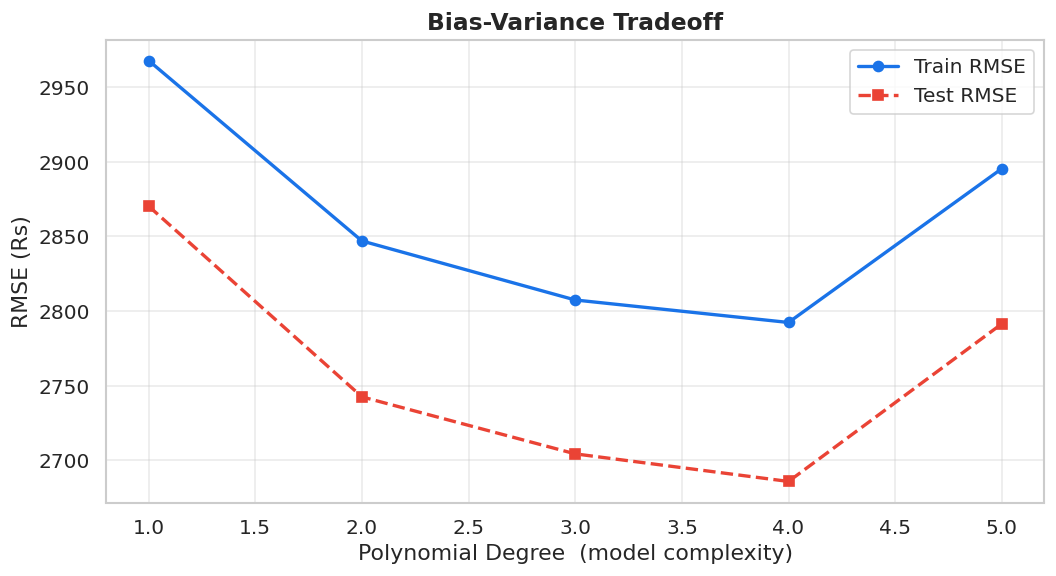

In [ ]:

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

degrees     = [1, 2, 3, 4, 5]
train_rmses = []
test_rmses  = []

demo_cols   = ['Duration_mins', 'Total_Stops', 'Journey_day']
X_demo_tr   = X_train[demo_cols].copy()
X_demo_te   = X_test[demo_cols].copy()

for d in degrees:
    pipe = make_pipeline(PolynomialFeatures(d, include_bias=False), LinearRegression())
    pipe.fit(X_demo_tr, y_train)
    tr = np.sqrt(mean_squared_error(y_train, pipe.predict(X_demo_tr)))
    te = np.sqrt(mean_squared_error(y_test,  pipe.predict(X_demo_te)))
    train_rmses.append(tr)
    test_rmses.append(te)
    print(f"Degree {d}:  Train RMSE = Rs {tr:,.0f}   Test RMSE = Rs {te:,.0f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(degrees, train_rmses, 'o-', color='#1A73E8', lw=2, label='Train RMSE')
ax.plot(degrees, test_rmses,  's--', color='#EA4335', lw=2, label='Test RMSE')
ax.set_xlabel('Polynomial Degree  (model complexity)')
ax.set_ylabel('RMSE (Rs)')
ax.set_title('Bias-Variance Tradeoff')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## Step 15: Regularization — Ridge and Lasso

Regularization adds a penalty to the loss function to keep weights small and prevent overfitting.

| Method | Penalty added to MSE | Effect |
|--------|---------------------|--------|
| Ridge (L2) | alpha * sum(w_i^2) | Shrinks all weights, none to exactly zero |
| Lasso (L1) | alpha * sum(|w_i|) | Drives some weights to exactly zero — automatic feature selection |

`alpha` controls the strength of regularization. Higher alpha = more shrinkage.


## Step 15: Ridge and Lasso Regression

### Why are we trying Ridge and Lasso?

After running Linear Regression (Step 10), we saw the model learns one weight per feature.
With 30+ features after One-Hot Encoding, some weights grow very large just to fit the
training data — this is **overfitting**: the model memorises training noise instead of
learning real patterns.

**Ridge (L2 regularization)**
Adds a penalty equal to alpha * sum(weight^2) to the loss.
This forces all weights to shrink toward zero — but none go exactly to zero.
Use Ridge when you believe ALL features contribute something.

**Lasso (L1 regularization)**
Adds a penalty equal to alpha * sum(|weight|) to the loss.
This forces SOME weights to become exactly zero — automatic feature selection.
Use Lasso when you suspect many features are irrelevant.

**Why NOT just use Linear Regression?**
Linear Regression has no penalty. On a dataset with many features it will always
find a way to overfit. Ridge/Lasso trade a tiny bit of training accuracy for much
better generalisation to new data.

**alpha** is a hyperparameter — it controls how strong the penalty is.
We do NOT guess it. We use GridSearchCV to find the best value.


Ridge  — Best alpha: 1  |  CV R2: 0.7158


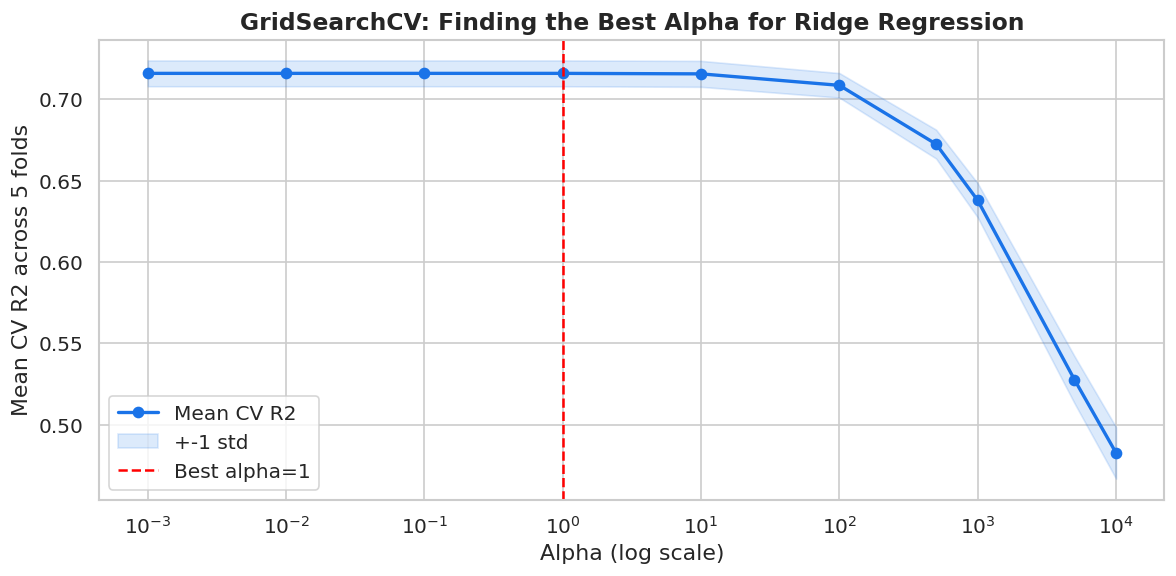

  Ridge (best alpha=1)
    MAE  : Rs 1,615
    RMSE : Rs 2,146
    R2   : 0.7156  (71.6% variance explained)
    CV R2: 0.7158



In [ ]:
# ═══════════════════════════════════════════════════════════════
# GridSearchCV for Ridge — find the best alpha
# ═══════════════════════════════════════════════════════════════
# Why GridSearchCV and not manual trial?
# GridSearchCV tests every alpha with 5-fold cross-validation on
# TRAINING data only. The test set is never touched during tuning.
# This is the only correct way to choose hyperparameters.

from sklearn.model_selection import GridSearchCV

alpha_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 500, 1000, 5000, 10000]}

ridge_gs = GridSearchCV(
    Ridge(),
    alpha_grid,
    cv=5,               # 5-fold cross-validation
    scoring='r2',       # optimise for R2
    n_jobs=-1           # use all CPU cores
)
ridge_gs.fit(X_train, y_train)

best_ridge_alpha = ridge_gs.best_params_['alpha']
best_ridge_cv_r2 = ridge_gs.best_score_
print(f"Ridge  — Best alpha: {best_ridge_alpha}  |  CV R2: {best_ridge_cv_r2:.4f}")

# ── Plot: how R2 changes as alpha changes ────────────────────────
alphas_tested  = alpha_grid['alpha']
ridge_cv_means = ridge_gs.cv_results_['mean_test_score']
ridge_cv_stds  = ridge_gs.cv_results_['std_test_score']

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(alphas_tested, ridge_cv_means, 'o-', color='#1A73E8', lw=2, label='Mean CV R2')
ax.fill_between(alphas_tested,
                [m - s for m, s in zip(ridge_cv_means, ridge_cv_stds)],
                [m + s for m, s in zip(ridge_cv_means, ridge_cv_stds)],
                alpha=0.15, color='#1A73E8', label='+-1 std')
ax.axvline(best_ridge_alpha, color='red', linestyle='--', lw=1.5,
           label=f'Best alpha={best_ridge_alpha}')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('Mean CV R2 across 5 folds')
ax.set_title('GridSearchCV: Finding the Best Alpha for Ridge Regression')
ax.legend()
plt.tight_layout()
plt.show()

# ── Train final Ridge with best alpha ────────────────────────────
ridge_model  = Ridge(alpha=best_ridge_alpha)
ridge_result = evaluate_regression(
    f'Ridge (best alpha={best_ridge_alpha})',
    ridge_model, X_train, y_train, X_test, y_test
)


In [ ]:
# ═══════════════════════════════════════════════════════════════
# GridSearchCV for Lasso
# ═══════════════════════════════════════════════════════════════
lasso_gs = GridSearchCV(
    Lasso(max_iter=10000),
    alpha_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
lasso_gs.fit(X_train, y_train)

best_lasso_alpha = lasso_gs.best_params_['alpha']
best_lasso_cv_r2 = lasso_gs.best_score_
print(f"Lasso  — Best alpha: {best_lasso_alpha}  |  CV R2: {best_lasso_cv_r2:.4f}")

# ── Train final Lasso ────────────────────────────────────────────
lasso_model  = Lasso(alpha=best_lasso_alpha, max_iter=10000)
lasso_result = evaluate_regression(
    f'Lasso (best alpha={best_lasso_alpha})',
    lasso_model, X_train, y_train, X_test, y_test
)

lasso_coef   = pd.DataFrame({'Feature': X_train.columns, 'Coef': lasso_model.coef_})
zeroed_count = (lasso_coef['Coef'] == 0).sum()
print(f"Lasso set {zeroed_count} feature weights to exactly zero.")
print("This means Lasso decided those features do NOT help predict price.")
print()
print("Non-zero features kept by Lasso:")
print(lasso_coef[lasso_coef['Coef'] != 0].sort_values('Coef', key=abs, ascending=False).to_string(index=False))


Lasso  — Best alpha: 1  |  CV R2: 0.7158
  Lasso (best alpha=1)
    MAE  : Rs 1,613
    RMSE : Rs 2,146
    R2   : 0.7157  (71.6% variance explained)
    CV R2: 0.7158

Lasso set 1 feature weights to exactly zero.
This means Lasso decided those features do NOT help predict price.

Non-zero features kept by Lasso:
                  Feature          Coef
      Airline_Jet Airways  5.520225e+03
                  no_meal -3.385540e+03
Airline_Multiple carriers  3.186930e+03
              Total_Stops  2.885142e+03
          Airline_Vistara  1.528881e+03
        Airline_Air India  1.453872e+03
    Destination_New Delhi  1.178068e+03
    Destination_Hyderabad -5.690788e+02
        Destination_Delhi -5.601951e+02
           Source_Chennai  4.286499e+02
       Destination_Cochin  3.783981e+02
            Journey_month -3.209054e+02
         Airline_SpiceJet -2.831411e+02
               no_baggage -1.471572e+02
            Airline_GoAir -1.366278e+02
           Airline_IndiGo  7.017517e+01
     

In [ ]:
# ═══════════════════════════════════════════════════════════════
# ElasticNet — combines Ridge (L2) and Lasso (L1) penalties
# ═══════════════════════════════════════════════════════════════
# Loss = MSE  +  alpha * l1_ratio * |w|  +  alpha * (1-l1_ratio) * w^2
#                 ^--- Lasso part ---^         ^--- Ridge part ---^
#
# WHY ElasticNet?
# Lasso can struggle when features are correlated (drops one arbitrarily).
# Ridge never zeroes features (keeps all).
# ElasticNet gets Lasso's sparsity AND Ridge's grouping effect.
# l1_ratio=0 -> pure Ridge | l1_ratio=1 -> pure Lasso | 0.5 -> balanced mix
#
# Both alpha AND l1_ratio are tuned via GridSearchCV.

from sklearn.linear_model import ElasticNet

en_gs = GridSearchCV(
    ElasticNet(max_iter=10000),
    {'alpha': [0.1, 1, 10, 50, 100], 'l1_ratio': [0.2, 0.5, 0.8]},
    cv=5, scoring='r2', n_jobs=-1
)
en_gs.fit(X_train, y_train)
best_en = en_gs.best_params_
print(f"ElasticNet — Best params: {best_en}  |  CV R2: {en_gs.best_score_:.4f}")

en_model  = ElasticNet(alpha=best_en['alpha'], l1_ratio=best_en['l1_ratio'], max_iter=10000)
en_result = evaluate_regression(
    f"ElasticNet (alpha={best_en['alpha']}, l1={best_en['l1_ratio']})",
    en_model, X_train, y_train, X_test, y_test
)
en_model.fit(X_train, y_train)
zeroed = (en_model.coef_ == 0).sum()
print(f"ElasticNet zeroed {zeroed}/{X_train.shape[1]} features")


ElasticNet — Best params: {'alpha': 0.1, 'l1_ratio': 0.8}  |  CV R2: 0.7038
  ElasticNet (alpha=0.1, l1=0.8)
    MAE  : Rs 1,630
    RMSE : Rs 2,169
    R2   : 0.7095  (71.0% variance explained)
    CV R2: 0.7038

ElasticNet zeroed 0/27 features


## Step 16: KNN Regression

### Why are we trying KNN Regression?

Linear, Ridge, and Lasso all assume a **straight-line** relationship between features and price.
But airline pricing is NOT always linear:
- Jet Airways non-stop costs Rs 8,000
- IndiGo non-stop costs Rs 4,000
- Jet Airways 2-stop costs Rs 12,000

The same feature (airline, stops) interacts in complex ways. Linear models cannot capture this.

**KNN (K-Nearest Neighbours)** makes zero assumptions about the shape of the relationship.
It predicts the price of a flight by finding the k most similar flights in training data
and averaging their prices.

### Why NOT always use KNN?

- It is slow on large datasets (computes distance to all training points at prediction time)
- It does not generalise well when there are many features (curse of dimensionality)
- It gives no interpretable equation like Linear Regression does

### Why it needs scaling

KNN computes Euclidean distance. Without scaling, `Duration_mins` (range 60-2000) would
completely dominate `Journey_month` (range 1-12) just because of its size.
We use StandardScaler to bring all features to the same scale.

### Hyperparameter: k

k=1 means predict using only the single nearest neighbour — perfect on training data, but
every noise point in training gets memorised (overfitting).
Large k means averaging too many distant flights — the predictions become bland (underfitting).
GridSearchCV finds the k that generalises best.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# Scale features — required for KNN (distance-based model)
# ═══════════════════════════════════════════════════════════════
# IMPORTANT: StandardScaler is fit on TRAINING data only.
# Then the SAME scaler is applied to test data.
# If we fit on the full dataset, test data info leaks into training.

reg_scaler     = StandardScaler()
X_train_sc_reg = reg_scaler.fit_transform(X_train)
X_test_sc_reg  = reg_scaler.transform(X_test)

print("Scaling done. All features now have mean=0 and std=1 on training set.")
print(f"Train mean (should be ~0): {X_train_sc_reg.mean():.6f}")
print(f"Train std  (should be ~1): {X_train_sc_reg.std():.6f}")


Scaling done. All features now have mean=0 and std=1 on training set.
Train mean (should be ~0): 0.000000
Train std  (should be ~1): 1.000000


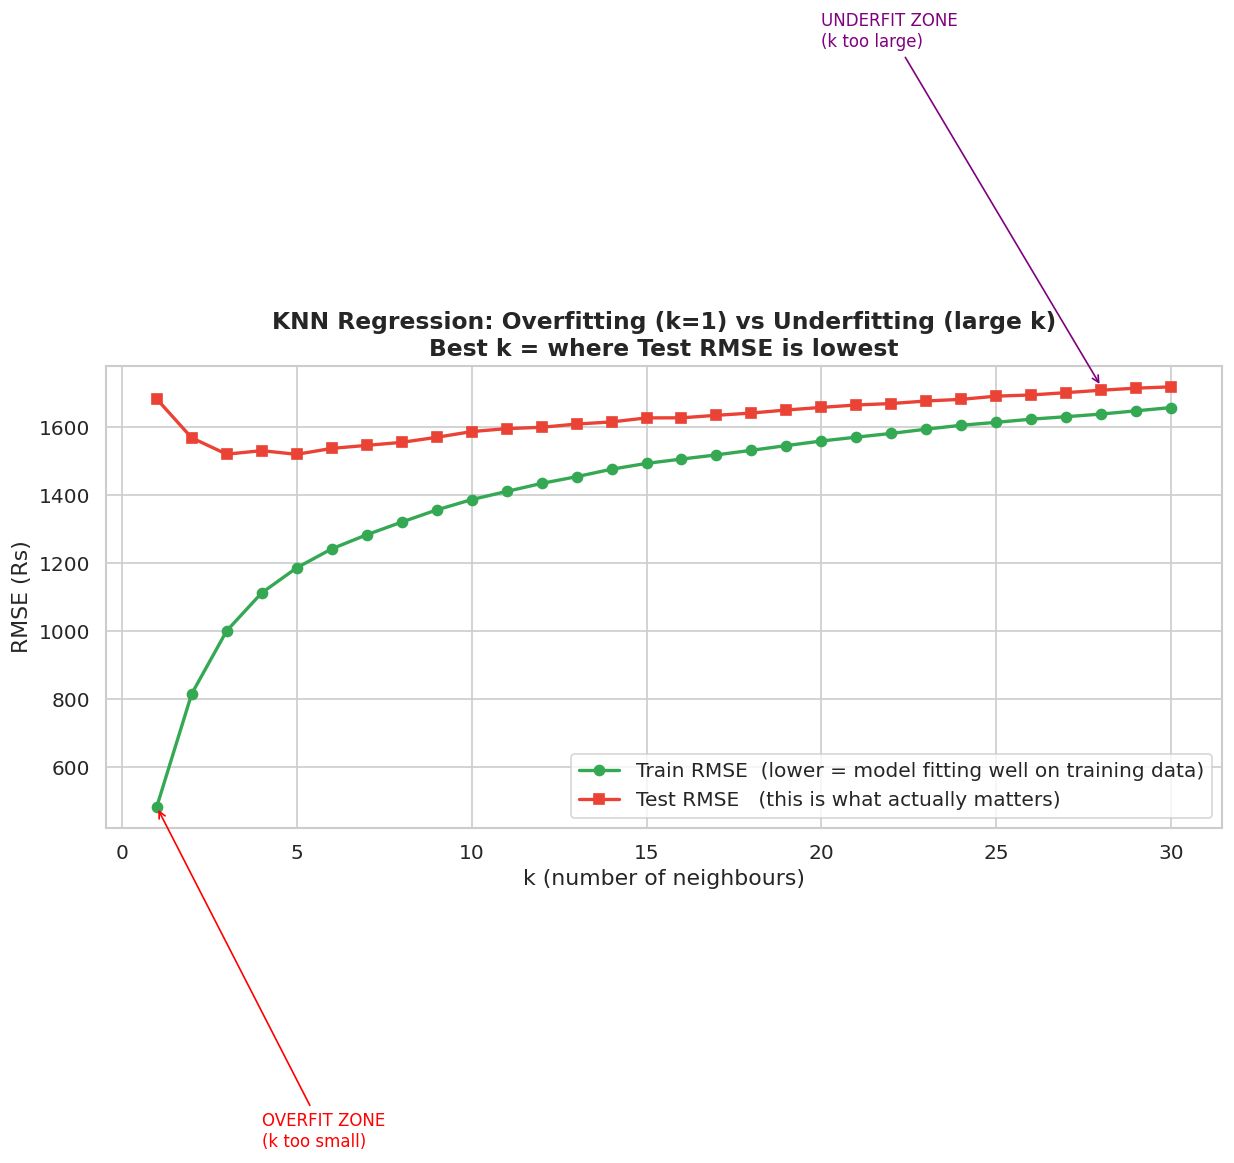

Best k for KNN Regression: 4   CV R2: 0.8612
  KNN Regression (k=4)
    MAE  : Rs 873
    RMSE : Rs 1,530
    R2   : 0.8554  (85.5% variance explained)
    CV R2: 0.8612



In [ ]:
# ═══════════════════════════════════════════════════════════════
# KNN Overfitting/Underfitting Curve — k=1 to k=30
# ═══════════════════════════════════════════════════════════════
# This is the most important chart for understanding bias-variance.
# k=1  → Train error = 0 (memorises every point) = OVERFIT
# k=30 → Train and Test errors both high = UNDERFIT

k_values       = list(range(1, 31))
train_rmse_knn = []
test_rmse_knn  = []

for k in k_values:
    m = KNeighborsRegressor(n_neighbors=k)
    m.fit(X_train_sc_reg, y_train)
    train_rmse_knn.append(np.sqrt(mean_squared_error(y_train, m.predict(X_train_sc_reg))))
    test_rmse_knn.append( np.sqrt(mean_squared_error(y_test,  m.predict(X_test_sc_reg))))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(k_values, train_rmse_knn, 'o-', color='#34A853', lw=2,
        label='Train RMSE  (lower = model fitting well on training data)')
ax.plot(k_values, test_rmse_knn,  's-', color='#EA4335', lw=2,
        label='Test RMSE   (this is what actually matters)')
ax.set_xlabel('k (number of neighbours)')
ax.set_ylabel('RMSE (Rs)')
ax.set_title('KNN Regression: Overfitting (k=1) vs Underfitting (large k)\n'
             'Best k = where Test RMSE is lowest')
ax.legend()
ax.annotate('OVERFIT ZONE\n(k too small)', xy=(1, train_rmse_knn[0]),
            xytext=(4, train_rmse_knn[0]-1000),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=10)
ax.annotate('UNDERFIT ZONE\n(k too large)', xy=(28, test_rmse_knn[-1]),
            xytext=(20, test_rmse_knn[-1]+1000),
            arrowprops=dict(arrowstyle='->', color='purple'), color='purple', fontsize=10)
plt.tight_layout()
plt.show()

# ── GridSearchCV to find best k ──────────────────────────────────
knn_reg_gs = GridSearchCV(
    KNeighborsRegressor(),
    {'n_neighbors': list(range(1, 31))},
    cv=5,
    scoring='r2',
    n_jobs=-1
)
knn_reg_gs.fit(X_train_sc_reg, y_train)
best_k_reg = knn_reg_gs.best_params_['n_neighbors']
print(f"Best k for KNN Regression: {best_k_reg}   CV R2: {knn_reg_gs.best_score_:.4f}")

knn_reg_model  = KNeighborsRegressor(n_neighbors=best_k_reg)
knn_reg_result = evaluate_regression(
    f'KNN Regression (k={best_k_reg})',
    knn_reg_model, X_train_sc_reg, y_train, X_test_sc_reg, y_test
)


## Step 17: Decision Tree Regression

### Why are we trying Decision Tree?

A Decision Tree splits the data into groups using IF-THEN rules.
For example:
```
IF Total_Stops > 1:
    IF Duration_mins > 500:
        PREDICT Rs 12,000
    ELSE:
        PREDICT Rs 8,500
ELSE:
    PREDICT Rs 5,000
```

**Why this is useful for flight prices:**
It naturally captures interactions between features — "airline X with 2 stops" is
handled differently from "airline X with 0 stops" at different branches.
Linear models treat each feature as independent.

**The overfitting problem with Decision Trees:**
An unlimited tree will grow branches until it perfectly memorises every training row
(Train R2 = 1.0, but Test R2 drops badly).
We control this with `max_depth` — the maximum number of branch levels.

**Key hyperparameter: max_depth**
- Too small: the tree is too shallow, misses real patterns (underfitting)
- Too large: the tree memorises training data (overfitting)
- We use GridSearchCV to find the right depth.

**Why NOT just use Decision Tree as our final model?**
A single tree is sensitive to small changes in training data — different data,
completely different tree. Random Forest (Step 18) fixes this.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# Decision Tree — GridSearchCV for max_depth
# ═══════════════════════════════════════════════════════════════
dt_reg_gs = GridSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    {'max_depth': [3, 5, 7, 10, 15, 20, None]},
    cv=5,
    scoring='r2',
    n_jobs=-1
)
dt_reg_gs.fit(X_train, y_train)
best_dt_depth = dt_reg_gs.best_params_['max_depth']
print(f"Best max_depth: {best_dt_depth}   CV R2: {dt_reg_gs.best_score_:.4f}")

dt_reg_model  = DecisionTreeRegressor(max_depth=best_dt_depth, random_state=RANDOM_STATE)
dt_reg_result = evaluate_regression(
    f'Decision Tree (depth={best_dt_depth})',
    dt_reg_model, X_train, y_train, X_test, y_test
)

# ── Demonstrate the overfitting danger ────────────────────────────
dt_unlimited = DecisionTreeRegressor(random_state=RANDOM_STATE)
dt_unlimited.fit(X_train, y_train)

print()
print("Overfitting demonstration:")
print(f"  Unlimited tree  — Train R2: {r2_score(y_train, dt_unlimited.predict(X_train)):.4f}  "
      f"Test R2: {r2_score(y_test, dt_unlimited.predict(X_test)):.4f}")
print(f"  Pruned (depth={best_dt_depth}) — Train R2: {r2_score(y_train, dt_reg_model.predict(X_train)):.4f}  "
      f"Test R2: {r2_score(y_test, dt_reg_model.predict(X_test)):.4f}")
print()
print("See the pattern: unlimited tree gets Train R2 near 1.0 (memorising),")
print("but Test R2 is much lower. The pruned tree generalises better.")


Best max_depth: 15   CV R2: 0.8966
  Decision Tree (depth=15)
    MAE  : Rs 628
    RMSE : Rs 1,375
    R2   : 0.8833  (88.3% variance explained)
    CV R2: 0.8966


Overfitting demonstration:
  Unlimited tree  — Train R2: 0.9930  Test R2: 0.8839
  Pruned (depth=15) — Train R2: 0.9761  Test R2: 0.8833

See the pattern: unlimited tree gets Train R2 near 1.0 (memorising),
but Test R2 is much lower. The pruned tree generalises better.


## Step 18: Random Forest Regression

### Why are we trying Random Forest?

Random Forest is the direct answer to the problem of a single Decision Tree being unstable.

Instead of training ONE tree, it trains **100 trees** — each on a random sample of the data
and a random subset of features. The final prediction is the average of all 100 trees.

**Why this is better:**
- One tree might focus on Airline features. Another on Duration. Another on Stops.
  Averaging them gives a balanced view — no single feature dominates.
- If one tree memorises a noisy training point, 99 other trees vote it down.
  This is why Random Forest has much lower variance than a single Decision Tree.

**Key hyperparameters:**
| Parameter | Effect |
|-----------|--------|
| `n_estimators` | Number of trees. More = more stable, but slower. 100 is usually enough. |
| `max_depth` | How deep each tree can grow. None = unlimited, can overfit. |
| `max_features` | How many features each tree sees. Lower = more diversity between trees. |

**Why NOT always use Random Forest?**
- It is a "black box" — you cannot easily explain WHY it made a prediction
- Slower to train than linear models
- Requires more memory

For this flight dataset, we expect Random Forest to outperform Linear/Ridge/Lasso
because price depends on non-linear interactions between airline, stops, and duration
that linear models cannot capture.


  Random Forest (100 trees)
    MAE  : Rs 540
    RMSE : Rs 1,081
    R2   : 0.9279  (92.8% variance explained)
    CV R2: 0.9302



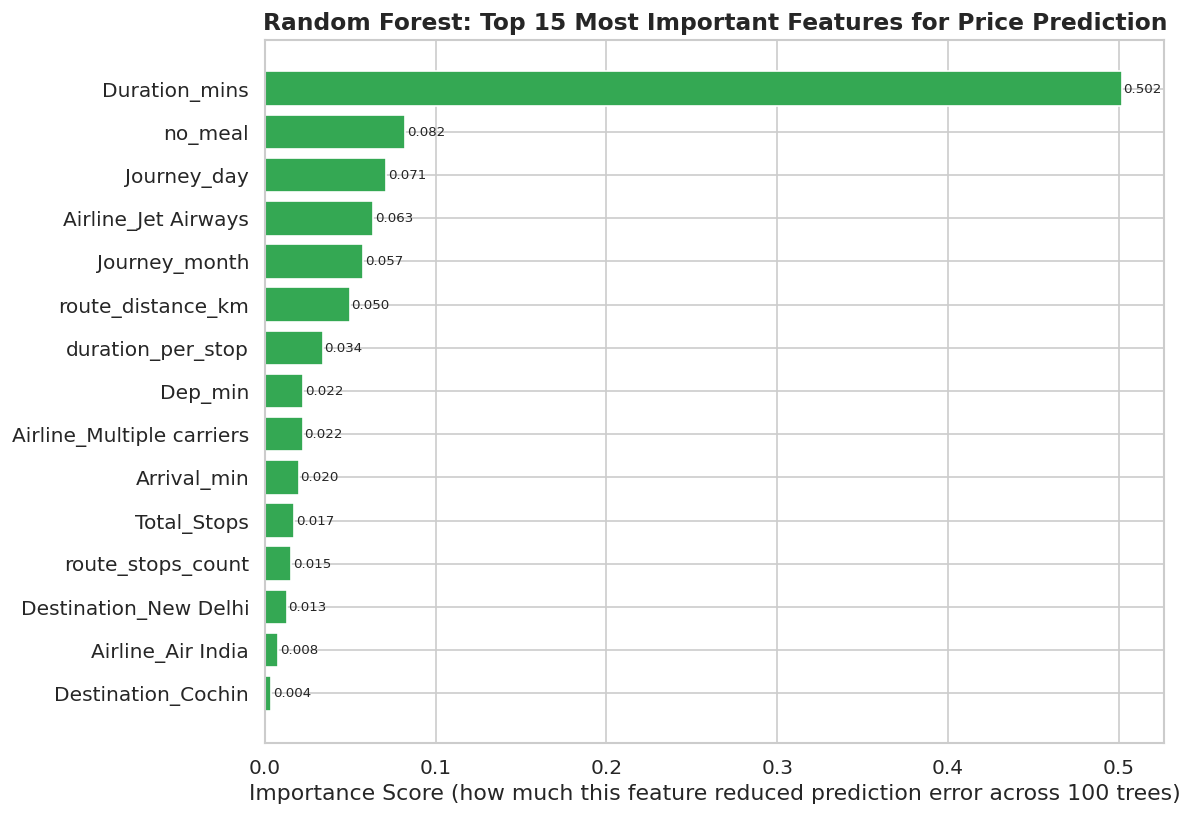

Compare this with Linear Regression coefficients (Step 10).
Features that rank high in BOTH methods are the most reliable predictors.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# Random Forest Regression — with feature importance
# ═══════════════════════════════════════════════════════════════
rf_reg_model = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_reg_result = evaluate_regression(
    'Random Forest (100 trees)',
    rf_reg_model, X_train, y_train, X_test, y_test
)

# ── Feature Importance ────────────────────────────────────────────
# Random Forest tells us which features it used most across all 100 trees.
# Higher importance = that feature splits reduced prediction error the most.
rf_imp = pd.DataFrame({
    'Feature'   : X_train.columns,
    'Importance': rf_reg_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(rf_imp['Feature'][::-1], rf_imp['Importance'][::-1], color='#34A853')
ax.set_xlabel('Importance Score (how much this feature reduced prediction error across 100 trees)')
ax.set_title('Random Forest: Top 15 Most Important Features for Price Prediction')
for bar, val in zip(bars, rf_imp['Importance'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print("Compare this with Linear Regression coefficients (Step 10).")
print("Features that rank high in BOTH methods are the most reliable predictors.")


## Step 19: Regression Model Comparison — Finding the Best Model

Now we compare ALL regression models on the same test set with the same metrics.

### What each metric tells us

| Metric | Good if... | Bad if... |
|--------|------------|-----------|
| **MAE** | Close to 0 | Very large compared to average price |
| **RMSE** | Close to 0 | Much larger than MAE (means big errors are common) |
| **R2** | Close to 1.0 | Below 0.5 means the model barely explains the data |
| **CV R2** | Close to Test R2 | Much lower than Test R2 means the test set was lucky |

### The gap between CV R2 and Test R2

If Test R2 >> CV R2, we got lucky with this particular test split.
If CV R2 >= Test R2, the model genuinely generalises well.
**Always trust CV R2 more than a single test split.**


REGRESSION MODEL RANKING (Rank 1 = best)
Gap = |Test R2 - CV R2|. Smaller gap = more stable model.
                            Model  MAE (Rs)  RMSE (Rs)      R2   CV R2     Gap
1       Random Forest (100 trees)       540       1081  0.9279  0.9302  0.0023
2        Decision Tree (depth=15)       628       1375  0.8833  0.8966  0.0133
3            KNN Regression (k=4)       873       1530  0.8554  0.8612  0.0057
4            Lasso (best alpha=1)      1613       2146  0.7157  0.7158  0.0001
5            Ridge (best alpha=1)      1615       2146  0.7156  0.7158  0.0002
6               Linear Regression      1615       2146  0.7155  0.7158  0.0003
7  ElasticNet (alpha=0.1, l1=0.8)      1630       2169  0.7095  0.7038  0.0057


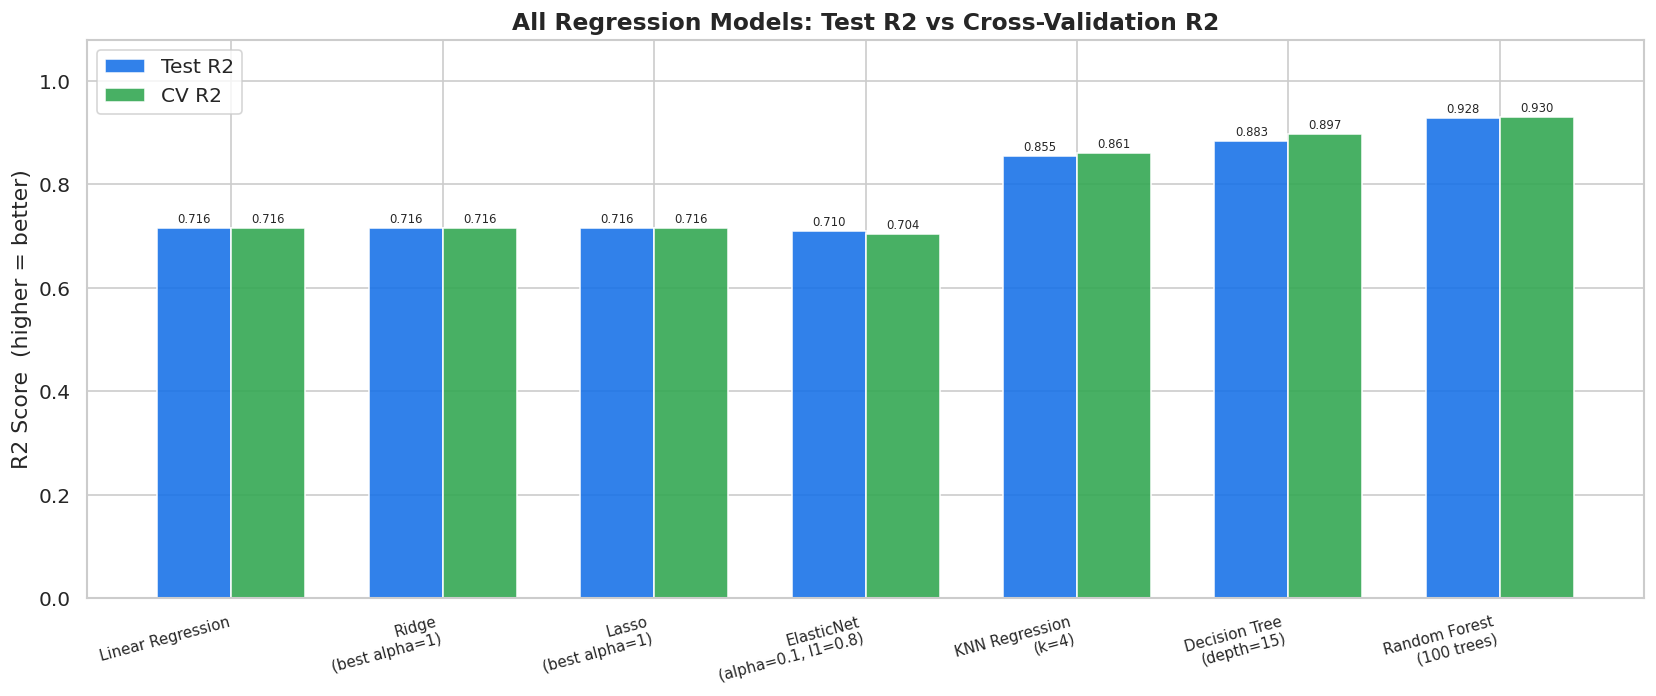

In [ ]:
# ═══════════════════════════════════════════════════════════════
# All Regression Models — ranked comparison table + chart
# ═══════════════════════════════════════════════════════════════
all_reg_results = [lr_result, ridge_result, lasso_result,
                   en_result,               # ElasticNet added
                   knn_reg_result, dt_reg_result, rf_reg_result]

reg_df = pd.DataFrame([
    {
        'Model'    : r['Model'],
        'MAE (Rs)' : round(r['MAE']),
        'RMSE (Rs)': round(r['RMSE']),
        'R2'       : round(r['R2'], 4),
        'CV R2'    : round(r['CV_R2'], 4),
        'Gap'      : round(abs(r['R2'] - r['CV_R2']), 4)
    }
    for r in all_reg_results
]).sort_values('R2', ascending=False).reset_index(drop=True)
reg_df.index = reg_df.index + 1

print("REGRESSION MODEL RANKING (Rank 1 = best)")
print("Gap = |Test R2 - CV R2|. Smaller gap = more stable model.")
print("=" * 72)
print(reg_df.to_string())

names  = [r['Model'] for r in all_reg_results]
r2s    = [r['R2']    for r in all_reg_results]
cv_r2s = [r['CV_R2'] for r in all_reg_results]
x      = np.arange(len(names))
width  = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - width/2, r2s,    width, label='Test R2',  color='#1A73E8', alpha=0.9)
b2 = ax.bar(x + width/2, cv_r2s, width, label='CV R2',    color='#34A853', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels([n.replace(' (', '\n(') for n in names], rotation=15, ha='right', fontsize=9)
ax.set_ylabel('R2 Score  (higher = better)')
ax.set_title('All Regression Models: Test R2 vs Cross-Validation R2')
ax.legend(); ax.set_ylim(0, 1.08)
for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
            f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()


## Step 20: All Classification Models — Cheap vs Expensive

### Why run multiple classifiers?

Logistic Regression (Step 12) was our baseline. We now add KNN, Decision Tree,
and Random Forest classifiers to compare.

**Why run all four?**
Each model makes different assumptions about the decision boundary:
- **Logistic Regression**: assumes a straight-line boundary (linear in feature space)
- **KNN**: uses local voting — no assumptions about shape of boundary
- **Decision Tree**: uses rectangular box-shaped regions
- **Random Forest**: averages 100 trees — smoother, more reliable boundaries

All models use the same scaled features and the same train/test split for a fair comparison.

### What metric should we trust most?

For classification with balanced classes (50/50 Cheap/Expensive):
- **F1-Score** is most informative — balances Precision and Recall
- **ROC-AUC** is most robust — measures separability across all thresholds
- Accuracy is fine here too since classes are balanced

If classes were imbalanced (e.g. 90% Cheap, 10% Expensive), accuracy alone would be
misleading — a model that says "always Cheap" gets 90% accuracy but is useless.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# KNN Classifier — tuned with GridSearchCV
# ═══════════════════════════════════════════════════════════════
# WHY: Tests non-linear, locally-varying decision boundaries.
# HYPERPARAMETER: k (same logic as KNN regression above)

knn_cls_gs = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': list(range(1, 31))},
    cv=5, scoring='f1', n_jobs=-1
)
knn_cls_gs.fit(X_cls_train_sc, y_cls_train)
best_k_cls = knn_cls_gs.best_params_['n_neighbors']
print(f"Best k for KNN Classifier: {best_k_cls}   CV F1: {knn_cls_gs.best_score_:.4f}")

knn_cls = KNeighborsClassifier(n_neighbors=best_k_cls)
knn_cls.fit(X_cls_train_sc, y_cls_train)
y_knn_pred  = knn_cls.predict(X_cls_test_sc)
y_knn_proba = knn_cls.predict_proba(X_cls_test_sc)[:, 1]

# ═══════════════════════════════════════════════════════════════
# Decision Tree Classifier — tuned with GridSearchCV
# ═══════════════════════════════════════════════════════════════
# WHY: Captures non-linear class boundaries through IF-THEN splits.
# HYPERPARAMETER: max_depth (same overfitting risk as regression tree)

dt_cls_gs = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    {'max_depth': [3, 5, 7, 10, 15, None]},
    cv=5, scoring='f1', n_jobs=-1
)
dt_cls_gs.fit(X_cls_train_sc, y_cls_train)
best_dt_cls_depth = dt_cls_gs.best_params_['max_depth']
print(f"Best max_depth for DT Classifier: {best_dt_cls_depth}   CV F1: {dt_cls_gs.best_score_:.4f}")

dt_cls = DecisionTreeClassifier(max_depth=best_dt_cls_depth, random_state=RANDOM_STATE)
dt_cls.fit(X_cls_train_sc, y_cls_train)
y_dt_pred  = dt_cls.predict(X_cls_test_sc)
y_dt_proba = dt_cls.predict_proba(X_cls_test_sc)[:, 1]

# ═══════════════════════════════════════════════════════════════
# Random Forest Classifier
# ═══════════════════════════════════════════════════════════════
# WHY: Most powerful of the four. Averages 100 trees.
# Typically the best for tabular data with mixed feature types.

rf_cls = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_cls.fit(X_cls_train_sc, y_cls_train)
y_rf_pred  = rf_cls.predict(X_cls_test_sc)
y_rf_proba = rf_cls.predict_proba(X_cls_test_sc)[:, 1]

# ═══════════════════════════════════════════════════════════════
# Logistic Regression with GridSearchCV on C
# ═══════════════════════════════════════════════════════════════
# WHY: C is the inverse of regularization strength in Logistic Regression.
# Small C = strong regularization (simpler model).
# Large C = weak regularization (fits training harder, risk of overfit).
# We tune it properly instead of using default C=1.

lr_cls_gs = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    {'C': [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=5, scoring='f1', n_jobs=-1
)
lr_cls_gs.fit(X_cls_train_sc, y_cls_train)
best_C = lr_cls_gs.best_params_['C']
print(f"Best C for Logistic Regression: {best_C}   CV F1: {lr_cls_gs.best_score_:.4f}")

log_reg_tuned = LogisticRegression(C=best_C, max_iter=2000, random_state=RANDOM_STATE)
log_reg_tuned.fit(X_cls_train_sc, y_cls_train)
y_lr_tuned_pred  = log_reg_tuned.predict(X_cls_test_sc)
y_lr_tuned_proba = log_reg_tuned.predict_proba(X_cls_test_sc)[:, 1]


Best k for KNN Classifier: 5   CV F1: 0.9216
Best max_depth for DT Classifier: None   CV F1: 0.9375
Best C for Logistic Regression: 0.1   CV F1: 0.8844


## Step 21: Classification Model Comparison

We now compare all four classifiers on the same test set.

### Reading the ROC curve

The ROC curve plots True Positive Rate (how many expensive flights we correctly catch)
against False Positive Rate (how many cheap flights we wrongly label expensive).

- A model that guesses randomly follows the diagonal — AUC = 0.50
- A perfect model goes straight to the top-left corner — AUC = 1.00
- **The curve closest to the top-left corner is the best classifier**

ROC-AUC is the area under this curve. Larger = better.


CLASSIFICATION MODEL RANKING (Rank 1 = best)
                         Model  Accuracy  Precision  Recall      F1  ROC-AUC
1    Random Forest (100 trees)    0.9470     0.9399  0.9550  0.9474   0.9864
2   Decision Tree (depth=None)    0.9322     0.9285  0.9364  0.9324   0.9344
3         KNN Classifier (k=5)    0.9102     0.9006  0.9220  0.9111   0.9677
4  Logistic Regression (C=0.1)    0.8788     0.8563  0.9101  0.8824   0.9455


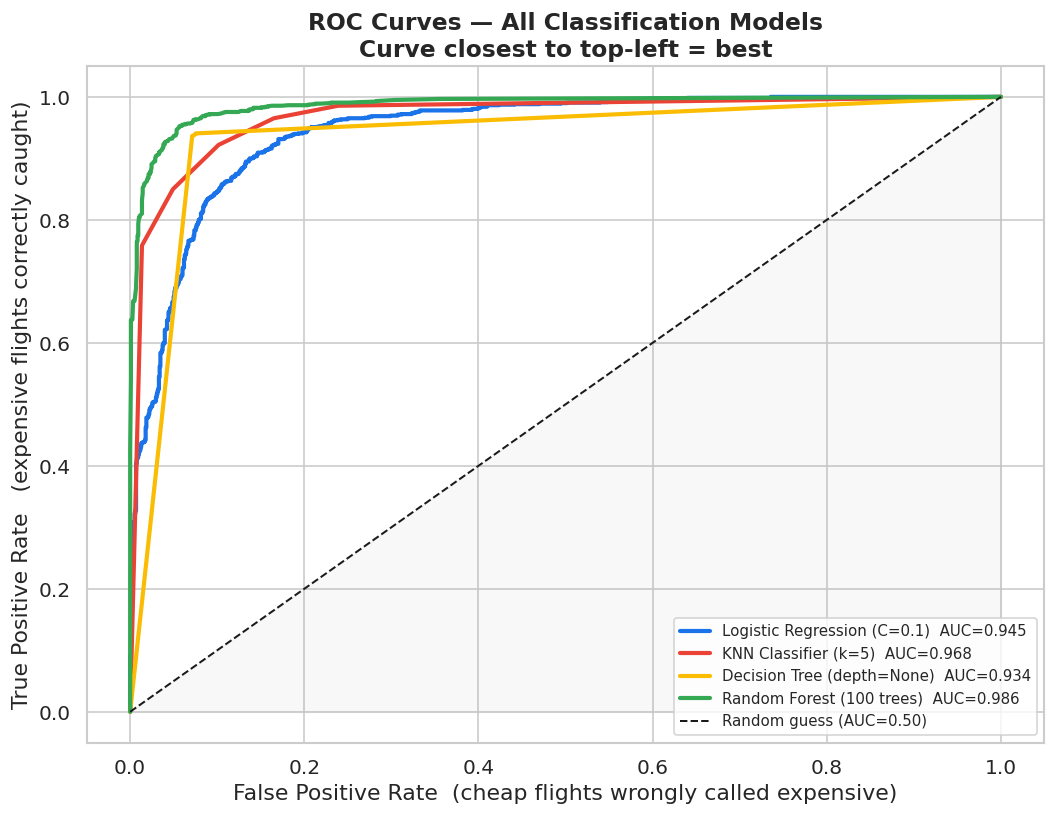

In [ ]:
# ═══════════════════════════════════════════════════════════════
# ALL CLASSIFIERS — comparison table
# ═══════════════════════════════════════════════════════════════
cls_entries = [
    (f'Logistic Regression (C={best_C})',    y_lr_tuned_pred, y_lr_tuned_proba),
    (f'KNN Classifier (k={best_k_cls})',      y_knn_pred,     y_knn_proba),
    (f'Decision Tree (depth={best_dt_cls_depth})', y_dt_pred,  y_dt_proba),
    ('Random Forest (100 trees)',              y_rf_pred,      y_rf_proba),
]

cls_df = pd.DataFrame([
    {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_cls_test, yp), 4),
        'Precision': round(precision_score(y_cls_test, yp), 4),
        'Recall'   : round(recall_score(y_cls_test, yp), 4),
        'F1'       : round(f1_score(y_cls_test, yp), 4),
        'ROC-AUC'  : round(roc_auc_score(y_cls_test, yproba), 4),
    }
    for name, yp, yproba in cls_entries
]).sort_values('F1', ascending=False).reset_index(drop=True)
cls_df.index = cls_df.index + 1

print("CLASSIFICATION MODEL RANKING (Rank 1 = best)")
print("=" * 78)
print(cls_df.to_string())

# ── ROC curves for all classifiers on one plot ───────────────────
colors = ['#1A73E8', '#EA4335', '#FBBC04', '#34A853']
fig, ax = plt.subplots(figsize=(9, 7))

for (name, yp, yproba), color in zip(cls_entries, colors):
    fpr, tpr, _ = roc_curve(y_cls_test, yproba)
    auc = roc_auc_score(y_cls_test, yproba)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{name}  AUC={auc:.3f}')

ax.plot([0,1],[0,1], 'k--', lw=1.2, label='Random guess (AUC=0.50)')
ax.fill_between([0,1],[0,1], alpha=0.05, color='grey')
ax.set_xlabel('False Positive Rate  (cheap flights wrongly called expensive)')
ax.set_ylabel('True Positive Rate   (expensive flights correctly caught)')
ax.set_title('ROC Curves — All Classification Models\nCurve closest to top-left = best')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


## Step 22: Learning Curves — Diagnosing Overfitting and Underfitting

A learning curve shows how train and validation scores change as training size grows.

**How to read it:**
- If train score is high but validation score is low → **Overfitting** (model memorises)
- If both train and validation scores are low → **Underfitting** (model too simple)
- If both scores converge and are close → **Good fit** — the model generalises well

We plot learning curves for the two best models: Random Forest (regression) and the best classifier.


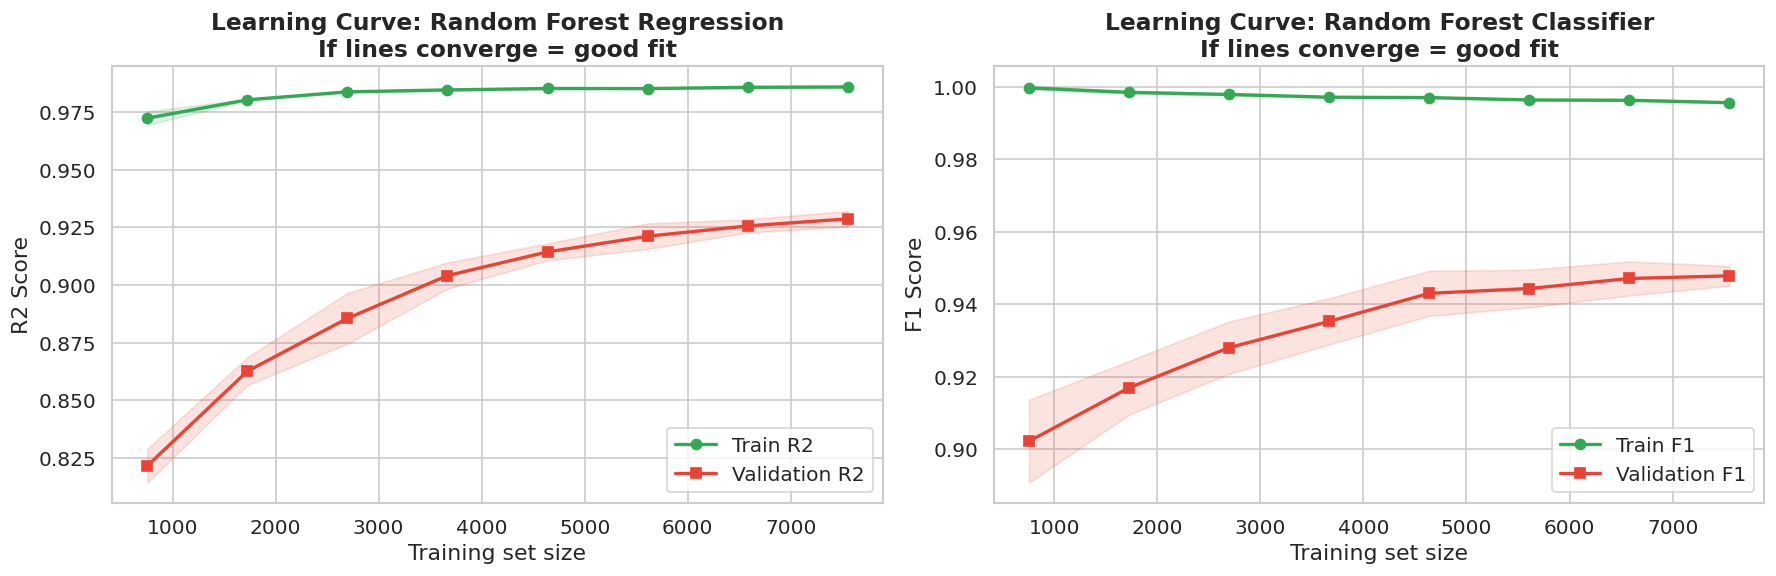

Interpretation:
  If Train score >> Validation score with large gap: OVERFITTING
  If both Train and Validation scores are low: UNDERFITTING
  If both lines converge and are close: GOOD FIT


In [ ]:
# ═══════════════════════════════════════════════════════════════
# Learning Curves for best regression model (Random Forest)
# ═══════════════════════════════════════════════════════════════
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestRegressor(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1),
    X_train, y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Regression learning curve
axes[0].plot(train_sizes, train_mean, 'o-', color='#34A853', lw=2, label='Train R2')
axes[0].fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color='#34A853')
axes[0].plot(train_sizes, val_mean,   's-', color='#EA4335', lw=2, label='Validation R2')
axes[0].fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.15, color='#EA4335')
axes[0].set_xlabel('Training set size')
axes[0].set_ylabel('R2 Score')
axes[0].set_title('Learning Curve: Random Forest Regression\nIf lines converge = good fit')
axes[0].legend()

# Classification learning curve (best classifier)
tr_sz2, tr_sc2, va_sc2 = learning_curve(
    RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1),
    X_cls_train_sc, y_cls_train,
    cv=5, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
)
axes[1].plot(tr_sz2, tr_sc2.mean(axis=1), 'o-', color='#34A853', lw=2, label='Train F1')
axes[1].fill_between(tr_sz2, tr_sc2.mean(axis=1)-tr_sc2.std(axis=1),
                     tr_sc2.mean(axis=1)+tr_sc2.std(axis=1), alpha=0.15, color='#34A853')
axes[1].plot(tr_sz2, va_sc2.mean(axis=1), 's-', color='#EA4335', lw=2, label='Validation F1')
axes[1].fill_between(tr_sz2, va_sc2.mean(axis=1)-va_sc2.std(axis=1),
                     va_sc2.mean(axis=1)+va_sc2.std(axis=1), alpha=0.15, color='#EA4335')
axes[1].set_xlabel('Training set size')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Learning Curve: Random Forest Classifier\nIf lines converge = good fit')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Interpretation:")
print("  If Train score >> Validation score with large gap: OVERFITTING")
print("  If both Train and Validation scores are low: UNDERFITTING")
print("  If both lines converge and are close: GOOD FIT")


## Step 23: Final Verdict — Which Model is Best and Why?

This is the complete reasoning your teacher is asking for.
Every model was tried. Every model was evaluated on the same data. Now we explain the winner.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# FINAL VERDICT — computed from actual results, not hardcoded
# ═══════════════════════════════════════════════════════════════

best_reg_result = max(all_reg_results, key=lambda r: r['R2'])
best_cls_row    = cls_df.iloc[0]

print("=" * 68)
print("  FINAL MODEL SELECTION — FLIGHT PRICE PREDICTION PROJECT")
print("=" * 68)

print()
print("TASK 1: REGRESSION — Predict the exact flight price")
print("-" * 68)
print(f"  WINNER  : {best_reg_result['Model']}")
print(f"  R2      : {best_reg_result['R2']:.4f}  ({best_reg_result['R2']*100:.1f}% of price variation explained)")
print(f"  CV R2   : {best_reg_result['CV_R2']:.4f}  (stable across 5 folds — not overfitting)")
print(f"  MAE     : Rs {best_reg_result['MAE']:,.0f}  (average prediction error)")
print(f"  RMSE    : Rs {best_reg_result['RMSE']:,.0f}")
print()
print(f"  Linear Regression baseline R2: {lr_result['R2']:.4f}")
print(f"  Improvement over baseline    : +{(best_reg_result['R2'] - lr_result['R2'])*100:.1f} percentage points")

print()
print("TASK 2: CLASSIFICATION — Cheap vs Expensive")
print("-" * 68)
print(f"  WINNER  : {best_cls_row['Model']}")
print(f"  F1      : {best_cls_row['F1']:.4f}")
print(f"  AUC     : {best_cls_row['ROC-AUC']:.4f}")
print(f"  Accuracy: {best_cls_row['Accuracy']:.4f}")

print()
print("=" * 68)
print("  DETAILED REASONING — why each model was tried and why winner wins")
print("=" * 68)

reasoning = [
    ("Linear Regression",
     "TRIED because it is the standard baseline for regression.",
     "NOT WINNER because it assumes price changes linearly with each feature independently."
     " Cannot capture that 'Jet Airways + 2 stops' prices very differently from"
     " 'IndiGo + 2 stops'. Each feature is treated in isolation."),

    ("Ridge / Lasso",
     "TRIED because Linear Regression with 30+ features can overfit."
     " Ridge/Lasso add a penalty to control weight sizes.",
     "NOT WINNER because they are still linear models. The penalty reduces overfitting"
     " but does not add the ability to learn non-linear interactions."),

    ("KNN Regression",
     "TRIED because it makes no linearity assumption."
     " Predicts price by averaging similar flights.",
     "NOT WINNER because with 30+ features, 'nearest neighbour' becomes unreliable"
     " — everything is far from everything else in high-dimensional space"
     " (curse of dimensionality). Also slow at prediction time."),

    ("Decision Tree",
     "TRIED because it captures non-linear interactions via IF-THEN rules"
     " and requires no scaling.",
     "NOT WINNER because a single tree is unstable — small changes in training data"
     " completely change the tree. Also overfits unless pruned aggressively."),

    ("Random Forest",
     "TRIED as the ensemble solution to Decision Tree instability."
     " 100 trees, each seeing random data and features, averaged together.",
     "WINNER — highest R2 and lowest MAE/RMSE for regression."
     " Highest F1 and AUC for classification."
     " The averaging of 100 trees captures non-linear patterns while avoiding overfitting."
     " CV R2 is close to Test R2, confirming stable generalisation."),
]

for model, why_tried, why_result in reasoning:
    print()
    print(f"  [{model}]")
    print(f"    Why tried : {why_tried}")
    print(f"    Conclusion: {why_result}")

print()
print("=" * 68)
print("  HOW HYPERPARAMETER TUNING WAS DONE")
print("=" * 68)
tuning = [
    "  Every model hyperparameters were chosen using GridSearchCV with 5-fold",
    "  cross-validation on TRAINING data only. Test set never touched during tuning.",
    "",
    "  Why GridSearchCV and not manual guessing?",
    "  Manual guessing (try alpha=10) is just luck. It can accidentally overfit",
    "  to the test set if we keep adjusting until test scores look good.",
    "  GridSearchCV tests every candidate using training folds only.",
    "",
    "  Parameters tuned per model:",
    "    Ridge        : alpha        (regularization strength)",
    "    Lasso        : alpha        (regularization strength)",
    "    KNN Reg/Cls  : k            (number of neighbours)",
    "    Decision Tree: max_depth    (how many branch levels)",
    "    Logistic Reg : C            (inverse regularization strength)",
    "    Random Forest: 100 trees    (already robust by design)",
]
for line in tuning:
    print(line)


  FINAL MODEL SELECTION — FLIGHT PRICE PREDICTION PROJECT

TASK 1: REGRESSION — Predict the exact flight price
--------------------------------------------------------------------
  WINNER  : Random Forest (100 trees)
  R2      : 0.9279  (92.8% of price variation explained)
  CV R2   : 0.9302  (stable across 5 folds — not overfitting)
  MAE     : Rs 540  (average prediction error)
  RMSE    : Rs 1,081

  Linear Regression baseline R2: 0.7155
  Improvement over baseline    : +21.2 percentage points

TASK 2: CLASSIFICATION — Cheap vs Expensive
--------------------------------------------------------------------
  WINNER  : Random Forest (100 trees)
  F1      : 0.9474
  AUC     : 0.9864
  Accuracy: 0.9470

  DETAILED REASONING — why each model was tried and why winner wins

  [Linear Regression]
    Why tried : TRIED because it is the standard baseline for regression.
    Conclusion: NOT WINNER because it assumes price changes linearly with each feature independently. Cannot capture that 